In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as mlt
import seaborn as sns
mlt.style.use('fivethirtyeight')
import plotly.express as px
import plotly.offline as py
import plotly.graph_objs as go
import plotly.tools as  tls 
from warnings import filterwarnings
filterwarnings('ignore')

In [2]:
ipl_matches = pd.read_csv('matches (1).csv')
delivery = pd.read_csv('deliveries (1).csv')


In [3]:
ipl_matches.head()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


In [4]:
delivery.head()

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN


In [5]:
ipl_matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 636 entries, 0 to 635
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               636 non-null    int64  
 1   season           636 non-null    int64  
 2   city             629 non-null    object 
 3   date             636 non-null    object 
 4   team1            636 non-null    object 
 5   team2            636 non-null    object 
 6   toss_winner      636 non-null    object 
 7   toss_decision    636 non-null    object 
 8   result           636 non-null    object 
 9   dl_applied       636 non-null    int64  
 10  winner           633 non-null    object 
 11  win_by_runs      636 non-null    int64  
 12  win_by_wickets   636 non-null    int64  
 13  player_of_match  633 non-null    object 
 14  venue            636 non-null    object 
 15  umpire1          635 non-null    object 
 16  umpire2          635 non-null    object 
 17  umpire3         

SINCE THE COLOUMN UMPRIE 3 IS FULL OF NAN VALUES IT IS NOT REQUIRED FOR ANALYSIS SO REMOVING THE COLUMN 

In [6]:
ipl_matches.drop(['umpire3'],axis=1,inplace=True)

In [7]:
ipl_matches.shape

(636, 17)

In [8]:
delivery.shape

(150460, 21)

In [9]:
ipl_matches.isnull().sum()

id                 0
season             0
city               7
date               0
team1              0
team2              0
toss_winner        0
toss_decision      0
result             0
dl_applied         0
winner             3
win_by_runs        0
win_by_wickets     0
player_of_match    3
venue              0
umpire1            1
umpire2            1
dtype: int64

In [10]:
delivery.isnull().sum()

match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batsman                  0
non_striker              0
bowler                   0
is_super_over            0
wide_runs                0
bye_runs                 0
legbye_runs              0
noball_runs              0
penalty_runs             0
batsman_runs             0
extra_runs               0
total_runs               0
player_dismissed    143022
dismissal_kind      143022
fielder             145091
dtype: int64

In [11]:
ipl_matches.columns

Index(['id', 'season', 'city', 'date', 'team1', 'team2', 'toss_winner',
       'toss_decision', 'result', 'dl_applied', 'winner', 'win_by_runs',
       'win_by_wickets', 'player_of_match', 'venue', 'umpire1', 'umpire2'],
      dtype='object')

In [12]:
delivery.columns

Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batsman', 'non_striker', 'bowler', 'is_super_over', 'wide_runs',
       'bye_runs', 'legbye_runs', 'noball_runs', 'penalty_runs',
       'batsman_runs', 'extra_runs', 'total_runs', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='object')

In [13]:
delivery.head()

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN


FILLING THE MISSING VALUE WITH APPROPIRATE VALUES 
IN delivery DATASET FILLING WITH ZERO MEANWHILE IPL_MATHCHES FILLING THE VALUE WITH UNKOWN SINCE THE COLOUMN INVOLVE WITH NAN VALUES ARE UMPIRES AND CITY AND WINNER AND PLAYER_OF_MATHCH TO AVOID CONFUSION WE REPLACE WITH UNKOWN

In [14]:
delivery.fillna(0,inplace=True)

In [15]:
ipl_matches.fillna('unkown',inplace=True)

In [16]:
ipl_matches.isnull().sum()

id                 0
season             0
city               0
date               0
team1              0
team2              0
toss_winner        0
toss_decision      0
result             0
dl_applied         0
winner             0
win_by_runs        0
win_by_wickets     0
player_of_match    0
venue              0
umpire1            0
umpire2            0
dtype: int64

In [17]:
ipl_matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 636 entries, 0 to 635
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               636 non-null    int64 
 1   season           636 non-null    int64 
 2   city             636 non-null    object
 3   date             636 non-null    object
 4   team1            636 non-null    object
 5   team2            636 non-null    object
 6   toss_winner      636 non-null    object
 7   toss_decision    636 non-null    object
 8   result           636 non-null    object
 9   dl_applied       636 non-null    int64 
 10  winner           636 non-null    object
 11  win_by_runs      636 non-null    int64 
 12  win_by_wickets   636 non-null    int64 
 13  player_of_match  636 non-null    object
 14  venue            636 non-null    object
 15  umpire1          636 non-null    object
 16  umpire2          636 non-null    object
dtypes: int64(5), object(12)
memory usag

HERE ALL VALUES ARE FORMATED WITH APPROPIRATE DATATYPE EXCPET DATE COLOUMN  SO WE NEED TO FORMAT THE DATE COLOUMN 

In [18]:
ipl_matches['date']=pd.to_datetime(ipl_matches['date'])

In [19]:
ipl_matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 636 entries, 0 to 635
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id               636 non-null    int64         
 1   season           636 non-null    int64         
 2   city             636 non-null    object        
 3   date             636 non-null    datetime64[ns]
 4   team1            636 non-null    object        
 5   team2            636 non-null    object        
 6   toss_winner      636 non-null    object        
 7   toss_decision    636 non-null    object        
 8   result           636 non-null    object        
 9   dl_applied       636 non-null    int64         
 10  winner           636 non-null    object        
 11  win_by_runs      636 non-null    int64         
 12  win_by_wickets   636 non-null    int64         
 13  player_of_match  636 non-null    object        
 14  venue            636 non-null    object   

In [20]:
ipl_matches['team1'].unique()

array(['Sunrisers Hyderabad', 'Mumbai Indians', 'Gujarat Lions',
       'Rising Pune Supergiant', 'Royal Challengers Bangalore',
       'Kolkata Knight Riders', 'Delhi Daredevils', 'Kings XI Punjab',
       'Chennai Super Kings', 'Rajasthan Royals', 'Deccan Chargers',
       'Kochi Tuskers Kerala', 'Pune Warriors', 'Rising Pune Supergiants'],
      dtype=object)

In [21]:
ipl_matches.replace(['Sunrisers Hyderabad', 'Mumbai Indians', 'Gujarat Lions',
       'Rising Pune Supergiant', 'Royal Challengers Bangalore',
       'Kolkata Knight Riders', 'Delhi Daredevils', 'Kings XI Punjab',
       'Chennai Super Kings', 'Rajasthan Royals', 'Deccan Chargers',
       'Kochi Tuskers Kerala', 'Pune Warriors', 'Rising Pune Supergiants'],
        ['SRH','MI','GT','RPS','RCB','KKR','DD','KXIP','CSK','RR','DEC','KTK','PW','RPS'],inplace=True)
delivery.replace(['Sunrisers Hyderabad', 'Mumbai Indians', 'Gujarat Lions',
       'Rising Pune Supergiant', 'Royal Challengers Bangalore',
       'Kolkata Knight Riders', 'Delhi Daredevils', 'Kings XI Punjab',
       'Chennai Super Kings', 'Rajasthan Royals', 'Deccan Chargers',
       'Kochi Tuskers Kerala', 'Pune Warriors', 'Rising Pune Supergiants'],
        ['SRH','MI','GT','RPS','RCB','KKR','DD','KXIP','CSK','RR','DEC','KTK','PW','RPS'],inplace=True)


In [22]:
ipl_matches.tail(10)

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2
626,627,2016,Kanpur,2016-05-19,KKR,GT,GT,field,normal,0,GT,0,6,DR Smith,Green Park,AK Chaudhary,CK Nandan
627,628,2016,Raipur,2016-05-20,SRH,DD,DD,field,normal,0,DD,0,6,KK Nair,Shaheed Veer Narayan Singh International Stadium,A Nand Kishore,BNJ Oxenford
628,629,2016,Visakhapatnam,2016-05-21,KXIP,RPS,KXIP,bat,normal,0,RPS,0,4,MS Dhoni,Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket St...,HDPK Dharmasena,Nitin Menon
629,630,2016,Kanpur,2016-05-21,MI,GT,GT,field,normal,0,GT,0,6,SK Raina,Green Park,AK Chaudhary,CK Nandan
630,631,2016,Kolkata,2016-05-22,KKR,SRH,SRH,field,normal,0,KKR,22,0,YK Pathan,Eden Gardens,KN Ananthapadmanabhan,M Erasmus
631,632,2016,Raipur,2016-05-22,DD,RCB,RCB,field,normal,0,RCB,0,6,V Kohli,Shaheed Veer Narayan Singh International Stadium,A Nand Kishore,BNJ Oxenford
632,633,2016,Bangalore,2016-05-24,GT,RCB,RCB,field,normal,0,RCB,0,4,AB de Villiers,M Chinnaswamy Stadium,AK Chaudhary,HDPK Dharmasena
633,634,2016,Delhi,2016-05-25,SRH,KKR,KKR,field,normal,0,SRH,22,0,MC Henriques,Feroz Shah Kotla,M Erasmus,C Shamshuddin
634,635,2016,Delhi,2016-05-27,GT,SRH,SRH,field,normal,0,SRH,0,4,DA Warner,Feroz Shah Kotla,M Erasmus,CK Nandan
635,636,2016,Bangalore,2016-05-29,SRH,RCB,SRH,bat,normal,0,SRH,8,0,BCJ Cutting,M Chinnaswamy Stadium,HDPK Dharmasena,BNJ Oxenford


In [23]:
print('TOTAL MATHCES PLAYED : ',ipl_matches.shape[0])
df=pd.DataFrame(ipl_matches['city'].unique(),columns=['VENUE NAME'])
display(df.style.background_gradient(cmap='PuBu').set_caption(f"Total Venue : {len(df)}"))
print('\n TEAMS PLAYED :',ipl_matches['team1'].unique())

TOTAL MATHCES PLAYED :  636


,VENUE NAME
0,Hyderabad
1,Pune
2,Rajkot
3,Indore
4,Bangalore
5,Mumbai
6,Kolkata
7,Delhi
8,Chandigarh
9,Kanpur



 TEAMS PLAYED : ['SRH' 'MI' 'GT' 'RPS' 'RCB' 'KKR' 'DD' 'KXIP' 'CSK' 'RR' 'DEC' 'KTK' 'PW']


In [24]:
umpire1_unique = ipl_matches['umpire1'].unique()
umpire2_unique = ipl_matches['umpire2'].unique()
all_umpires = pd.DataFrame(np.unique(np.concatenate([umpire1_unique, umpire2_unique])),columns=['Umpire Name'])
display(all_umpires.style.background_gradient(cmap='PuBu').set_caption(f"Total Umpires: {len(all_umpires)}"))

,Umpire Name
0,A Deshmukh
1,A Nand Kishore
2,AK Chaudhary
3,AL Hill
4,AM Saheba
5,AV Jayaprakash
6,AY Dandekar
7,Aleem Dar
8,Asad Rauf
9,BF Bowden


In [25]:

print((ipl_matches['player_of_match'].value_counts()).idxmax(),':he is the man of the match ')
print((ipl_matches['winner'].value_counts()).idxmax(),':this team won the highest number of the matches')

CH Gayle :he is the man of the match 
MI :this team won the highest number of the matches


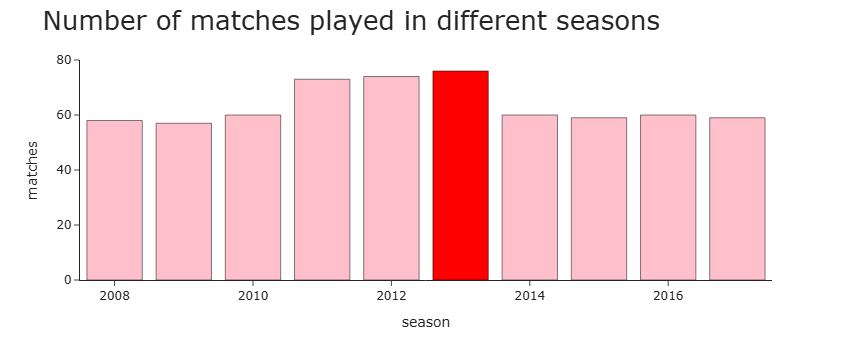

In [26]:
matches_per_season = ipl_matches.groupby(['season'])['id'].count().reset_index().rename(columns={'id':'matches'})
matches_per_season.style.background_gradient(cmap='pink')
colors = ['pink',] * 13
colors[5] = 'red'

fig = px.bar(data_frame=matches_per_season, 
             x='season',  
             y='matches',  
             labels=dict(x="Season", y="Number of Matches"))

fig.update_layout(title="Number of matches played in different seasons",
                  title_font={'size': 26}, 
                  template='simple_white',)  


fig.update_traces(marker_color=colors, marker_line_color='black')

fig.show()

player of the match over the seaon

In [27]:
player_of_the_match = pd.DataFrame(ipl_matches['player_of_match'].value_counts()).head(10)
print(player_of_the_match)

                 count
player_of_match       
CH Gayle            18
YK Pathan           16
AB de Villiers      15
DA Warner           15
SK Raina            14
RG Sharma           14
MS Dhoni            13
G Gambhir           13
AM Rahane           12
MEK Hussey          12


In [28]:
ipl_matches.iloc[[ipl_matches['win_by_runs'].idxmax()]]

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2
43,44,2017,Delhi,2017-05-06,MI,DD,DD,field,normal,0,MI,146,0,LMP Simmons,Feroz Shah Kotla,Nitin Menon,CK Nandan


In [29]:
ipl_matches.iloc[[ipl_matches['win_by_wickets'].idxmax()]]

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2
2,3,2017,Rajkot,2017-04-07,GT,KKR,KKR,field,normal,0,KKR,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan


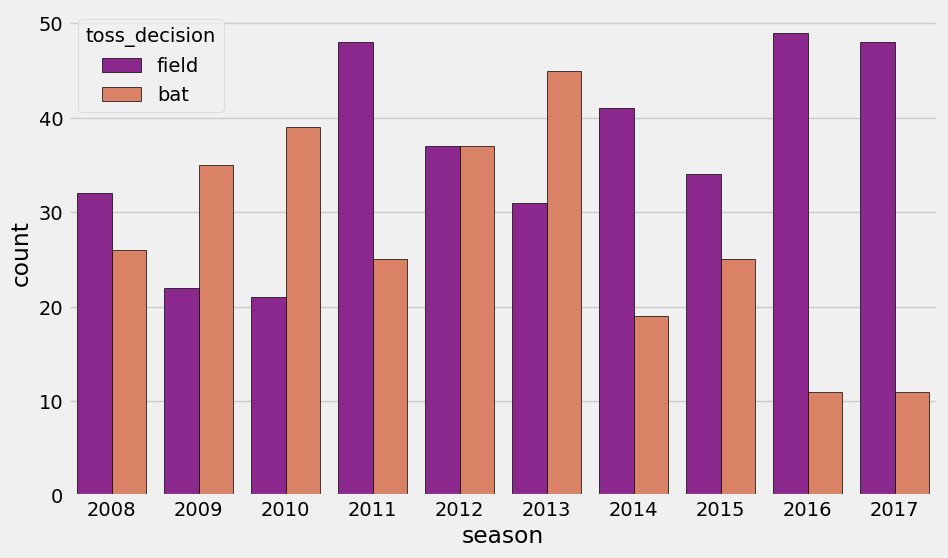

In [30]:
mlt.subplots(figsize=(10,6))
sns.countplot(x='season',hue='toss_decision',data=ipl_matches,palette='plasma',edgecolor='black')
mlt.show()

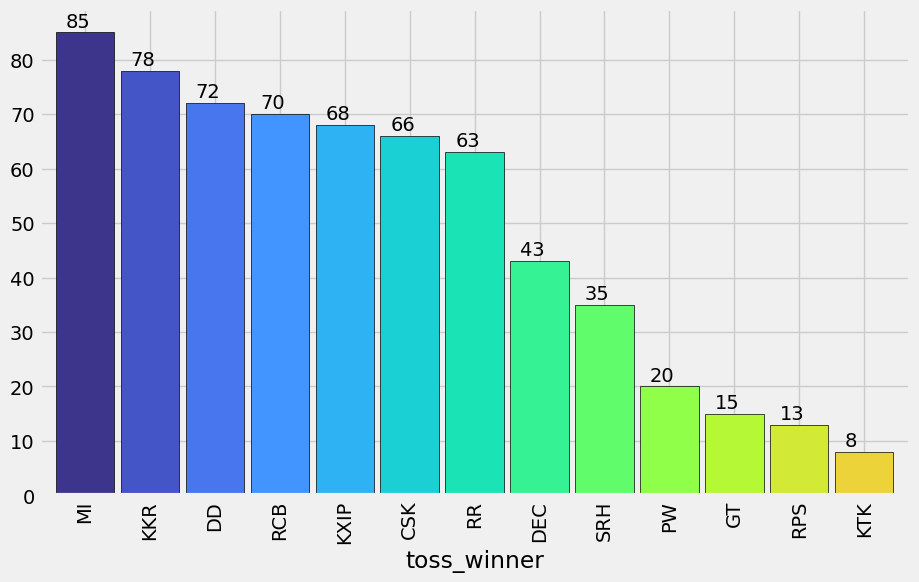

In [31]:
mlt.subplots(figsize=(10,6))
ax=ipl_matches['toss_winner'].value_counts().plot.bar(width=0.9,color=sns.color_palette('turbo',20),edgecolor='black')
for p in ax.patches:
    ax.annotate(format(p.get_height()),(p.get_x()+0.15,p.get_height()+1))
mlt.show()

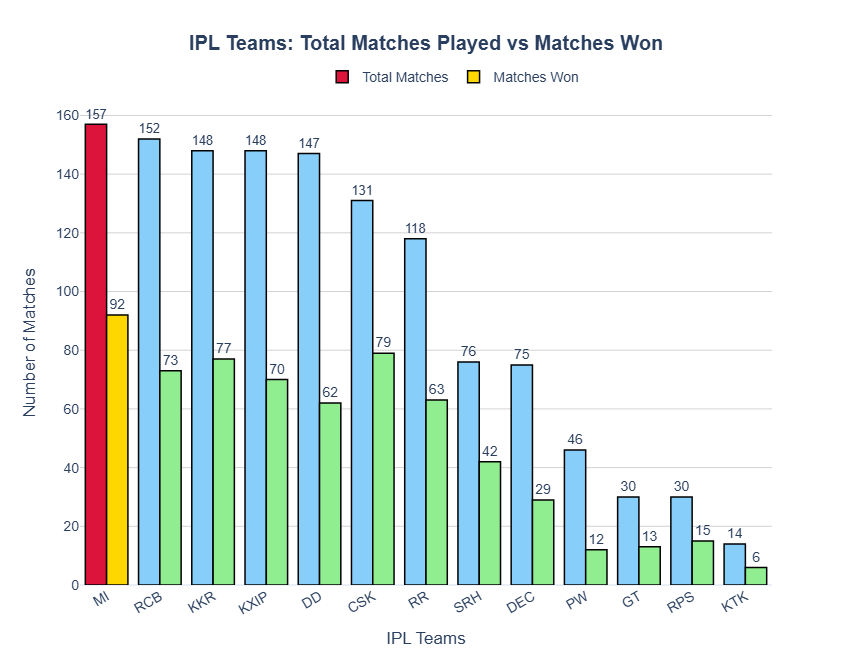

In [32]:
matches_played = pd.concat([
    ipl_matches['team1'],
    ipl_matches['team2']
])

matches_played = (
    matches_played
    .value_counts()
    .reset_index()
)

matches_played.columns = ['Team', 'Total Matches']

wins = (
    ipl_matches['winner']
    .value_counts()
    .reset_index()
)

wins.columns = ['Team', 'Wins']


matches_played = matches_played.merge(
    wins,
    on='Team',
    how='left'
)

matches_played['Wins'] = matches_played['Wins'].fillna(0).astype(int)


matches_played = matches_played.sort_values(
    by='Total Matches',
    ascending=False
).reset_index(drop=True)



match_colors = ['lightskyblue'] * len(matches_played)
match_colors[matches_played['Total Matches'].idxmax()] = 'crimson'

win_colors = ['lightgreen'] * len(matches_played)
win_colors[matches_played['Wins'].idxmax()] = 'gold'


fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=matches_played['Team'],
        y=matches_played['Total Matches'],
        name='Total Matches',
        marker=dict(
            color=match_colors,
            line=dict(color='black', width=1.5)
        ),
        text=matches_played['Total Matches'],
        textposition='outside',
        hovertemplate='<b>%{x}</b><br>Total Matches: %{y}<extra></extra>'
    )
)


fig.add_trace(
    go.Bar(
        x=matches_played['Team'],
        y=matches_played['Wins'],
        name='Matches Won',
        marker=dict(
            color=win_colors,
            line=dict(color='black', width=1.5)
        ),
        text=matches_played['Wins'],
        textposition='outside',
        hovertemplate='<b>%{x}</b><br>Matches Won: %{y}<extra></extra>'
    )
)



fig.update_layout(
    title='<b>IPL Teams: Total Matches Played vs Matches Won</b>',
    title_x=0.5,
    template='plotly_white',
    barmode='group',
    width=1200,
    height=650,
    font=dict(
        family='Arial',
        size=14
    ),
    xaxis=dict(
        title='IPL Teams',
        tickangle=-30,
        showgrid=False
    ),
    yaxis=dict(
        title='Number of Matches',
        showgrid=True,
        gridcolor='lightgray'
    ),
    hovermode='x unified',
    legend=dict(
        orientation='h',
        y=1.08,
        x=0.35
    )
)

fig.show()

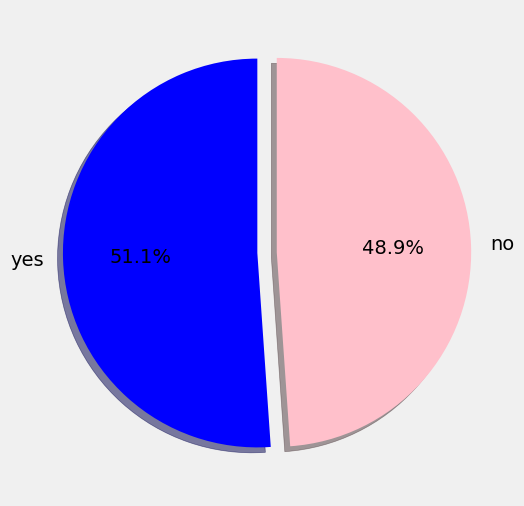

In [33]:
df=ipl_matches[ipl_matches['toss_winner']==ipl_matches['winner']]
slices=[len(df),(636-len(df))]
labels=['yes','no']
mlt.pie(slices,labels=labels,startangle=90,shadow=True,explode=(0,0.1),autopct='%1.1f%%',colors=['blue','pink'])
fig=mlt.gcf()
fig.set_size_inches(6,6)
mlt.show()
        

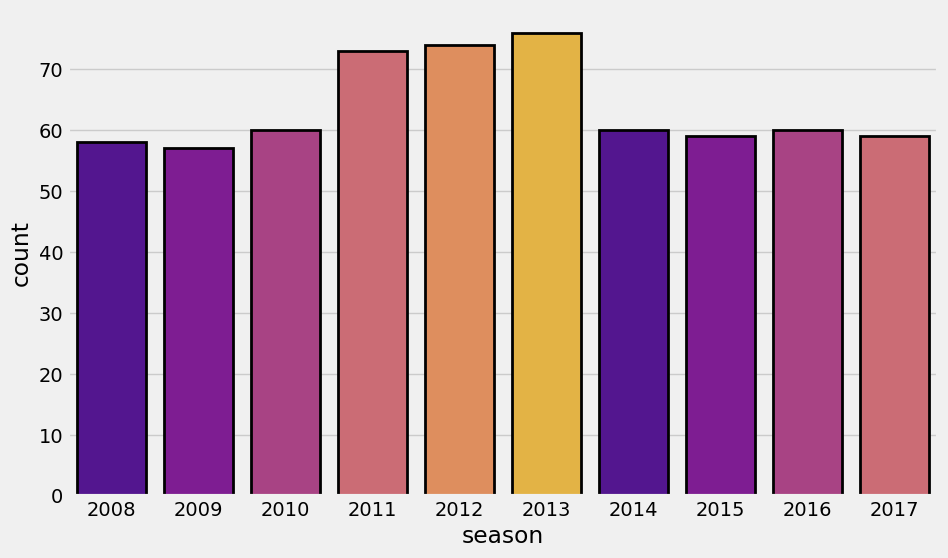

In [34]:
mlt.subplots(figsize=(10,6))
sns.countplot(x='season',data=ipl_matches,palette=sns.color_palette('plasma'),edgecolor='black',linewidth=2)
mlt.show()

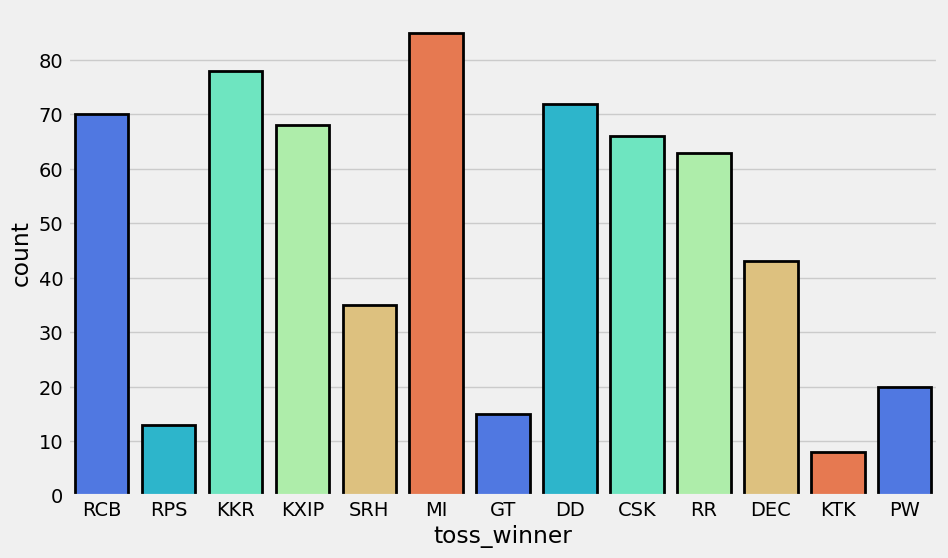

In [35]:
mlt.subplots(figsize=(10,6))
sns.countplot(x='toss_winner',data=ipl_matches,palette=sns.color_palette('rainbow'),edgecolor='black',linewidth=2)
mlt.show()

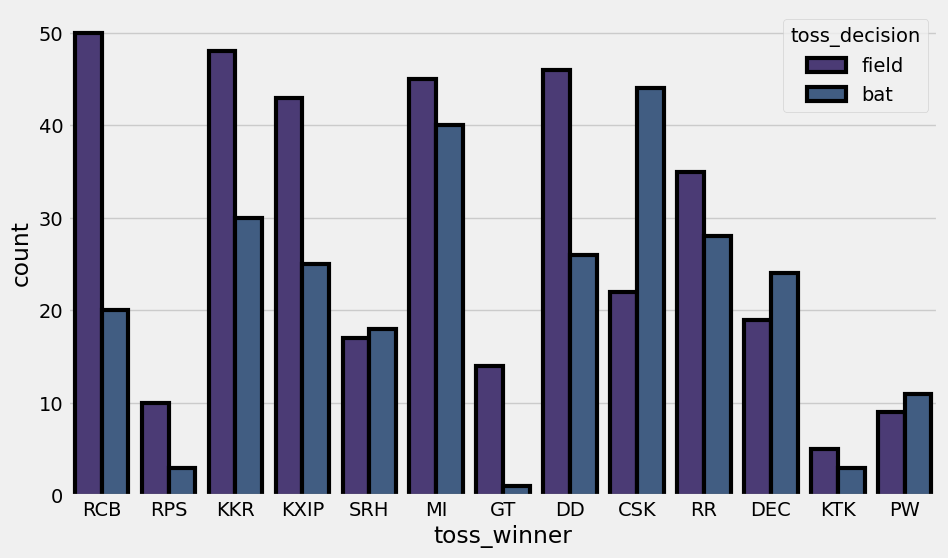

In [36]:
mlt.subplots(figsize=(10,6))
sns.countplot(x='toss_winner',hue='toss_decision',data=ipl_matches,palette=sns.color_palette('viridis'),edgecolor='black',linewidth=3)
mlt.show()

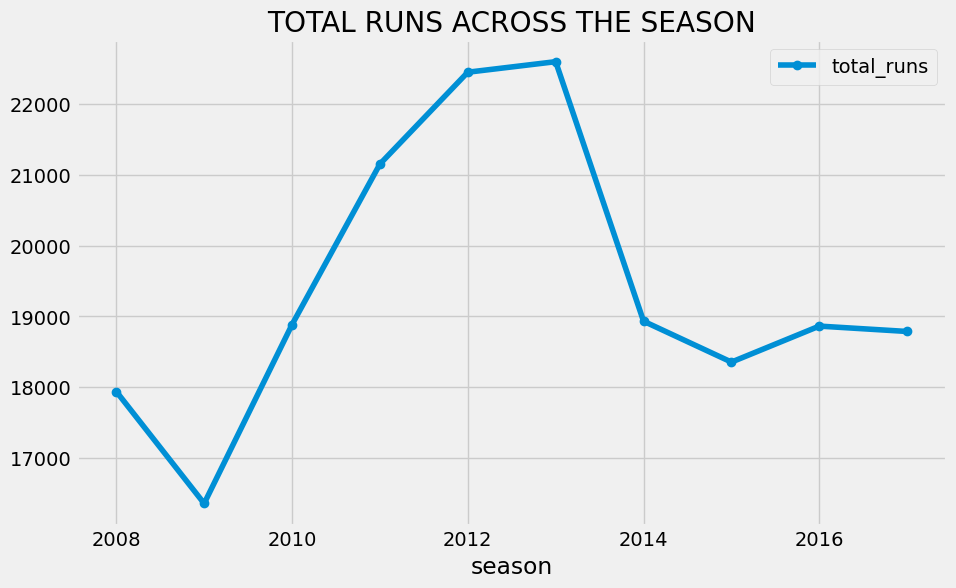

In [37]:
batsmen=ipl_matches[['id','season']].merge(delivery,left_on='id',right_on='match_id',how='left').drop('id',axis=1)
season=batsmen.groupby(['season'])['total_runs'].sum().reset_index()
season.set_index('season').plot(marker='o')
mlt.gcf().set_size_inches(10,6)
mlt.title("TOTAL RUNS ACROSS THE SEASON")
mlt.show()

   Season  Total Matches  Total Runs  Runs per Match
0    2008             58       17937          309.26
1    2009             57       16353          286.89
2    2010             60       18883          314.72
3    2011             73       21154          289.78
4    2012             74       22453          303.42
5    2013             76       22602          297.39
6    2014             60       18931          315.52
7    2015             59       18353          311.07
8    2016             60       18862          314.37
9    2017             59       18786          318.41


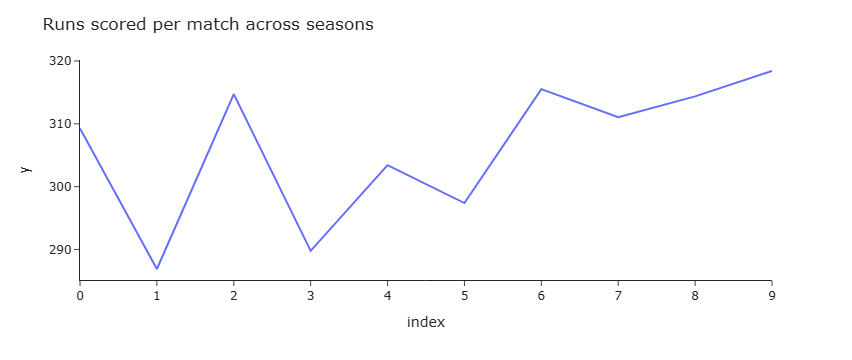

In [38]:
matches_per_season = (
    ipl_matches
    .groupby('season')['id']
    .nunique()
    .reset_index(name='Total Matches')
)
runs_per_season = (
    season
    .groupby('season')['total_runs']
    .sum()
    .reset_index(name='Total Runs')
)
season_summary = pd.merge(
    matches_per_season,
    runs_per_season,
    on='season'
)

season_summary['Runs per Match'] = (
    season_summary['Total Runs'] /
    season_summary['Total Matches']
).round(2)

season_summary.rename(columns={'season': 'Season'}, inplace=True)

print(season_summary)
fig = px.line(runs_per_season, x=runs_per_season.index, y=season_summary['Runs per Match'])
fig.update_layout(title="Runs scored per match across seasons",
                  template='simple_white'     
                  )
fig.show()


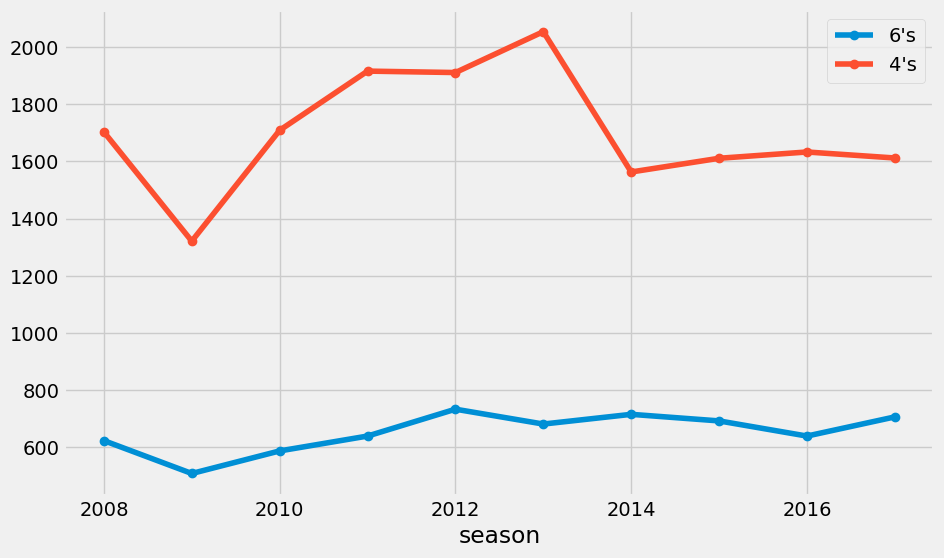

In [39]:
Season_six=batsmen.groupby('season')['batsman_runs'].agg(lambda x:(x==6).sum()).reset_index()
Season_boundaries=batsmen.groupby('season')['batsman_runs'].agg(lambda x:(x==4).sum()).reset_index()
Season_six=Season_six.merge(Season_boundaries,left_on='season',right_on='season',how='left')
Season_six = Season_six.rename(columns={'batsman_runs_x': "6's", 'batsman_runs_y': "4's"})
Season_six.set_index('season')[["6's","4's"]].plot(marker='o')
fig=mlt.gcf()
fig.set_size_inches(10,6)
mlt.show()

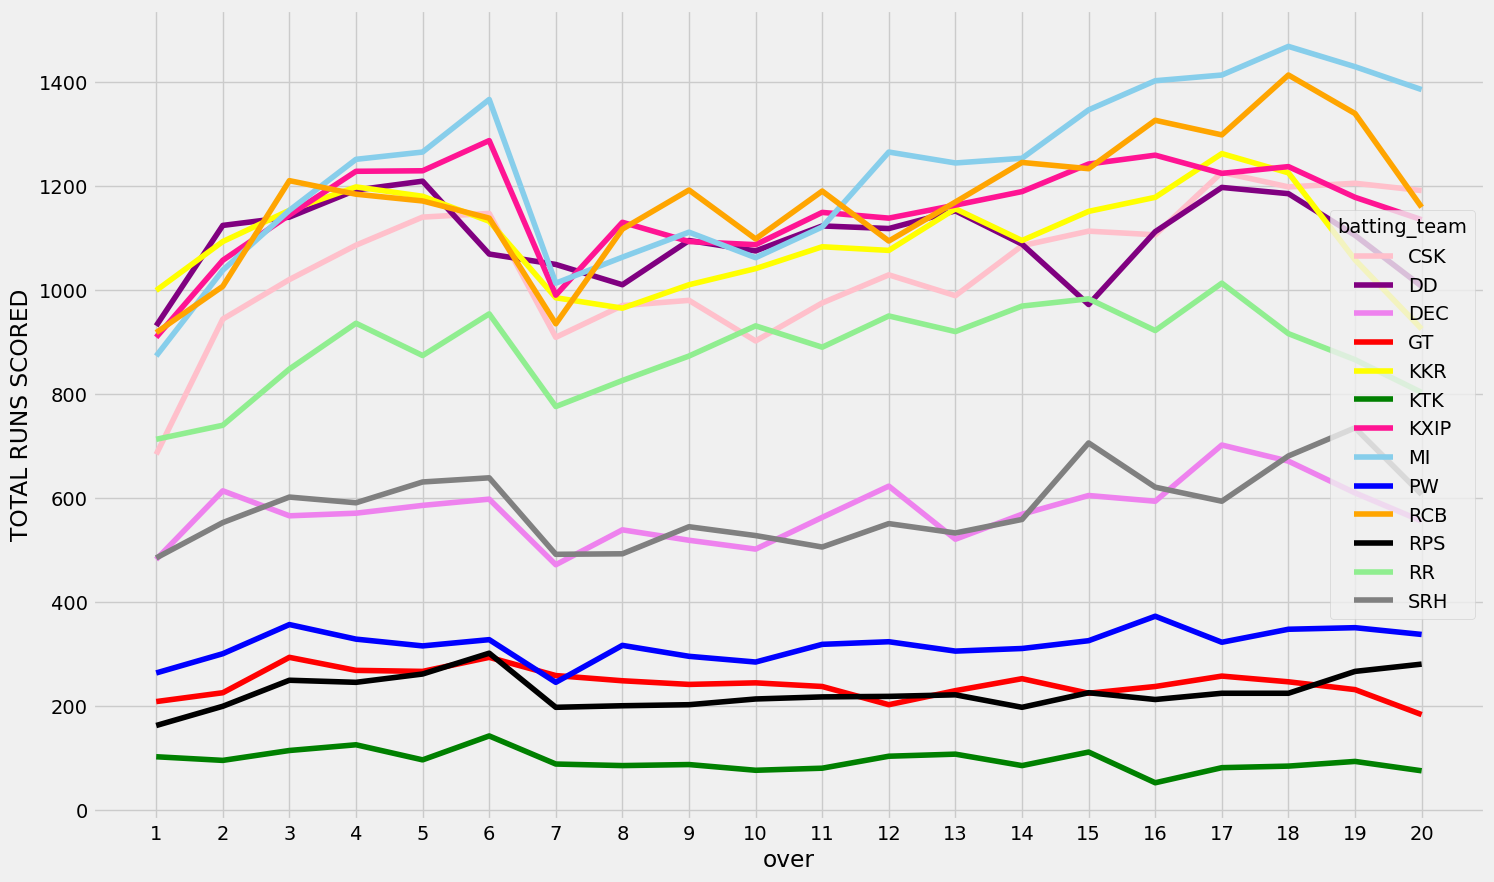

In [40]:
matches_played_byteams = delivery.groupby('batting_team').size().reset_index(name='Total Matches')
matches_played_byteams = matches_played_byteams.set_index('batting_team')
runs_per_over = delivery.pivot_table(index=['over'], columns='batting_team', values='total_runs', aggfunc=sum)

runs_per_over[(matches_played_byteams[matches_played_byteams['Total Matches'] > 50].index)].plot(
    color=['pink', 'purple', 'violet', 'red', 'yellow', 'green', 'deeppink', 'skyblue','blue','orange','black','lightgreen','grey']
)
x = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
mlt.xticks(x)  
mlt.ylabel("TOTAL RUNS SCORED") 
fig = mlt.gcf() 
fig.set_size_inches(16, 10)
mlt.show() 

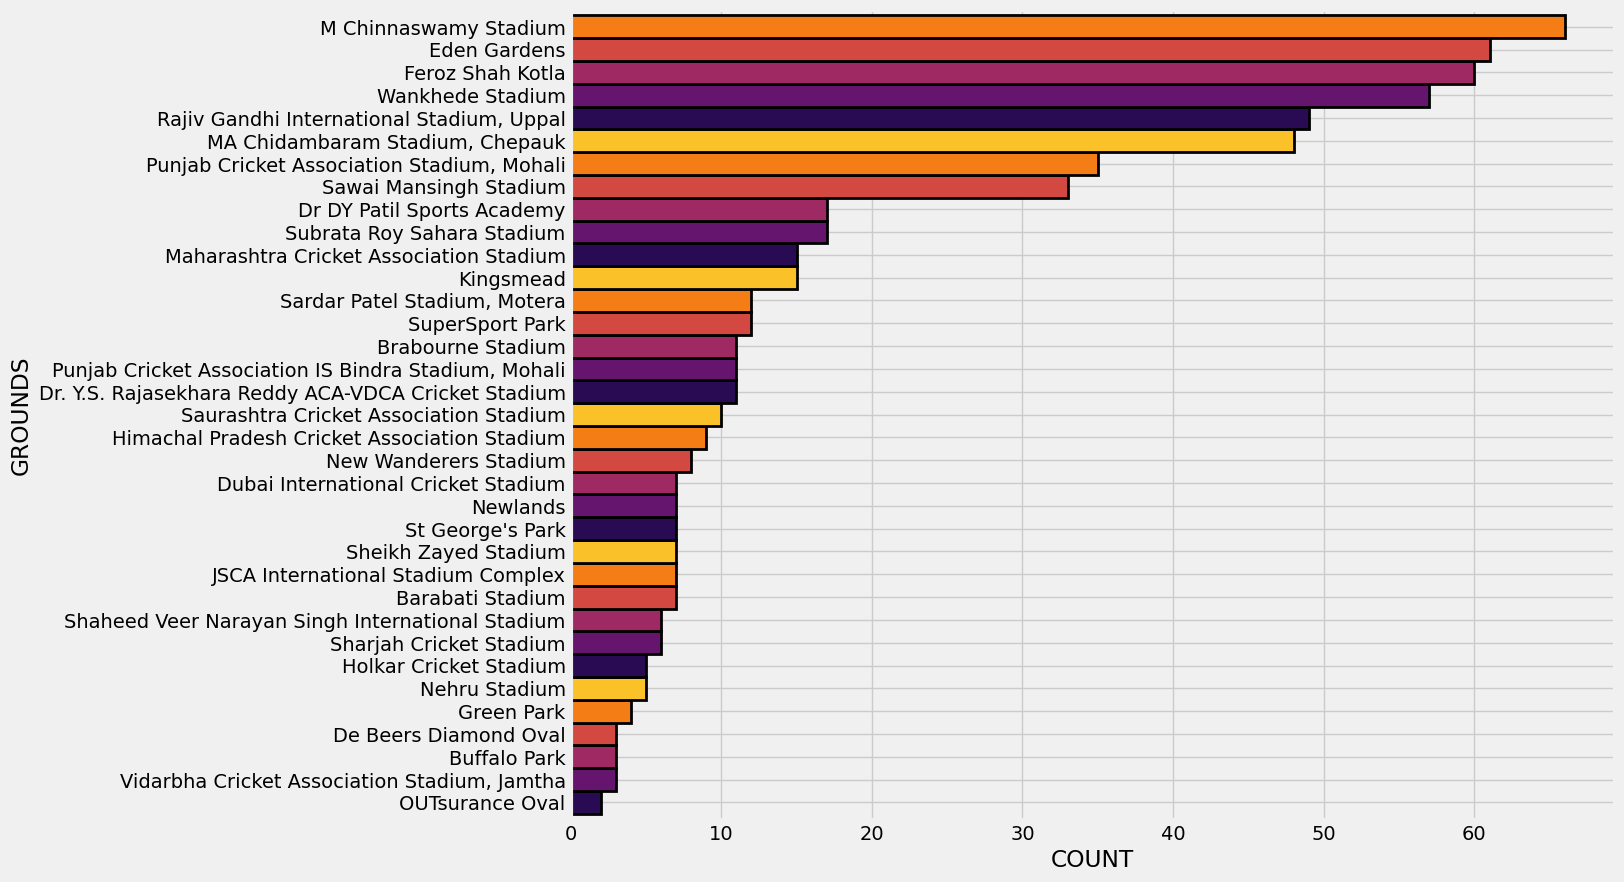

In [41]:
mlt.subplots(figsize=(10,15))
ax=ipl_matches['venue'].value_counts().sort_values(ascending=True).plot.barh(
    figsize=(12,10),
    width=1.0,
    color=sns.color_palette("inferno"),
    edgecolor='black',
    linewidth=2
)
ax.set_xlabel('COUNT')
ax.set_ylabel('GROUNDS')
fig.tight_layout()
mlt.show()


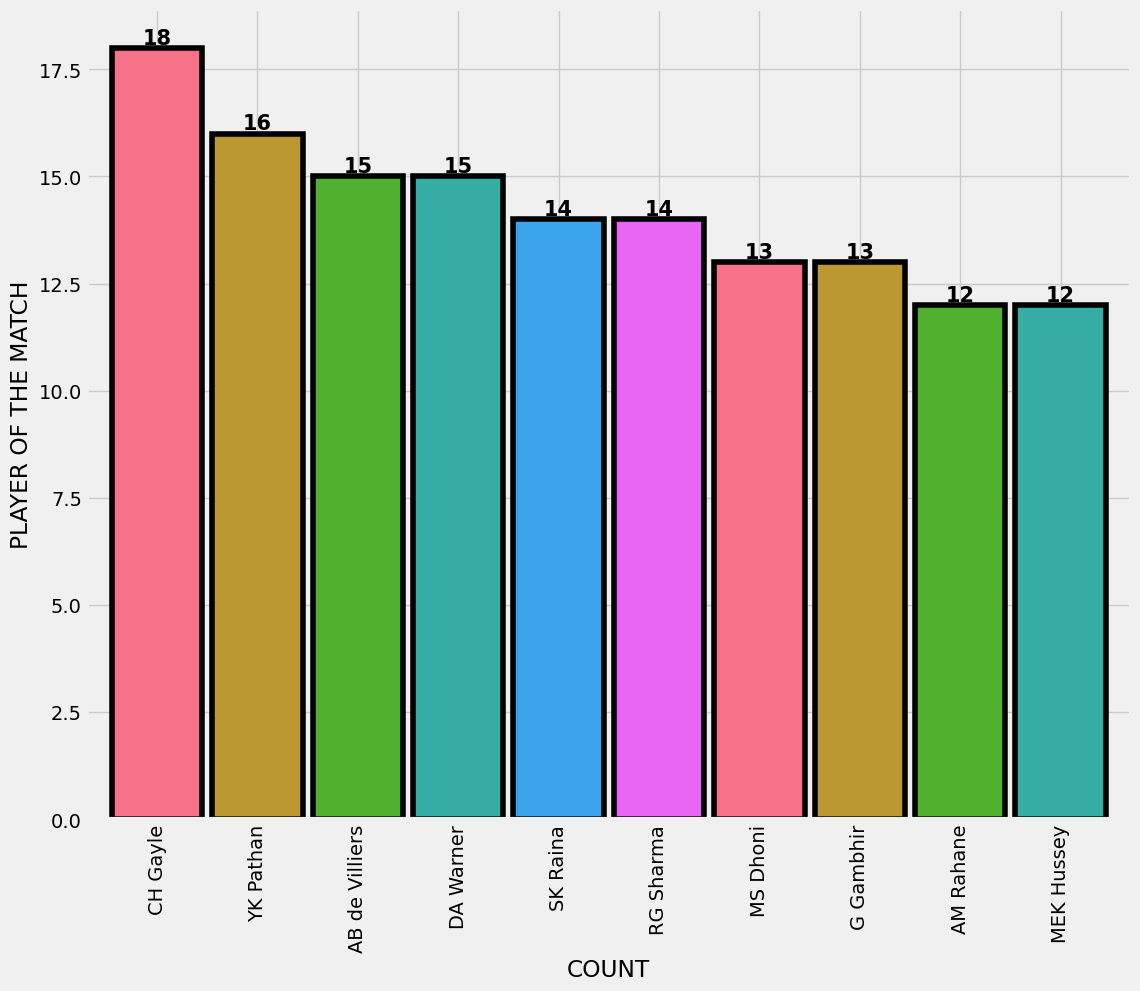

In [42]:
ax=ipl_matches['player_of_match'].value_counts().head(10).plot.bar(
    figsize=(12,10),
    width=0.9, 
    color=sns.color_palette("husl"),
    edgecolor='black',
    linewidth=4
)
for p in ax.patches:
    ax.annotate(
        format((p.get_height())),
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=15,
        fontweight='bold'
    )
ax.set_xlabel('COUNT')
ax.set_ylabel('PLAYER OF THE MATCH')
fig.tight_layout()
mlt.show()

In [43]:
winner_by_year = []

for i in range(2008, 2017):
    season_matches = ipl_matches[ipl_matches['season'] == i]
    winner = season_matches.iloc[-1]['winner']

    winner_by_year.append([i, winner])

winner_by_year = pd.DataFrame(
    winner_by_year,
    columns=['Season', 'Champion']
)

winner_by_year.style.set_caption("IPL Winners by Season").background_gradient(cmap='flare')
    

,Season,Champion
0,2008,RR
1,2009,DEC
2,2010,CSK
3,2011,CSK
4,2012,KKR
5,2013,MI
6,2014,KKR
7,2015,MI
8,2016,SRH


In [44]:
print("\nTOTAL MATCHES WITH SUPER OVERS :",delivery[delivery['is_super_over']==1].match_id.nunique())


TOTAL MATCHES WITH SUPER OVERS : 7


In [45]:
teams=['SRH','MI','GT','RPS','RCB','KKR','DD','KXIP','CSK','RR','DEC','KTK','PW','RPS']
play=delivery[delivery['is_super_over']==1].batting_team.unique()
play=list(play)
print("TEAMS WHO HAVEN'T EVER PLAYED A SUPER OVER ARE:",list(set(teams)-set(play)))

TEAMS WHO HAVEN'T EVER PLAYED A SUPER OVER ARE: ['PW', 'DEC', 'RPS', 'KTK']


In [46]:
lay=delivery[delivery['is_super_over']==1].batting_team.unique()
play=list(play)
print("TEAMS WHO  EVER PLAYED A SUPER OVER ARE:",list(set(play)))

TEAMS WHO  EVER PLAYED A SUPER OVER ARE: ['GT', 'KKR', 'RR', 'MI', 'KXIP', 'DD', 'SRH', 'RCB', 'CSK']


###MI VS KKR

In [47]:
def team1_vs_team2(team1, team2):
    mt1 = ipl_matches[
        (
            ((ipl_matches['team1'] == team1) & (ipl_matches['team2'] == team2))
            |
            ((ipl_matches['team1'] == team2) & (ipl_matches['team2'] == team1))
            &((ipl_matches['team1']==team2)|(ipl_matches['team2'] == team2))
        )
    ]
    mlt.figure(figsize=(12,6))
    sns.countplot(
        data=mt1,
        x='season',
        hue='winner',
        palette='winter',
        edgecolor='black'
    )

    
    mlt.xlabel('Season')
    mlt.ylabel('Number of Matches')

    mlt.xticks(rotation=45)

    mlt.legend(
        title='Winner',
        loc='upper right',
        bbox_to_anchor=(0.5, 1.15),
        ncol=2
    )

    mlt.tight_layout()
    mlt.show()

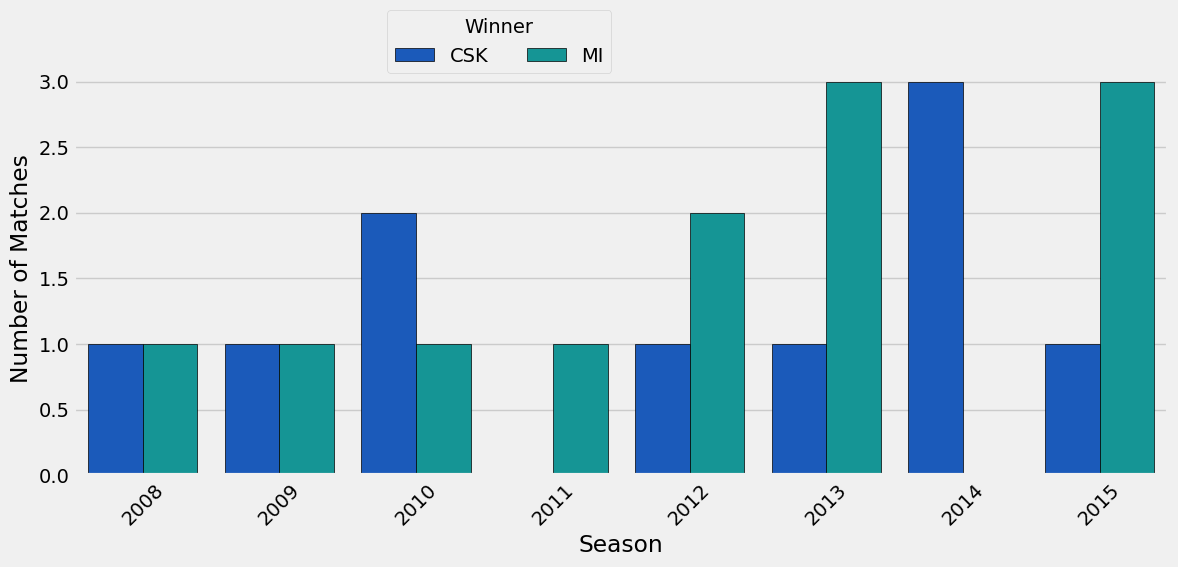

In [48]:
team1_vs_team2('MI','CSK')

In [49]:
ipl_matches.head()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2
0,1,2017,Hyderabad,2017-04-05,SRH,RCB,RCB,field,normal,0,SRH,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong
1,2,2017,Pune,2017-04-06,MI,RPS,RPS,field,normal,0,RPS,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi
2,3,2017,Rajkot,2017-04-07,GT,KKR,KKR,field,normal,0,KKR,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan
3,4,2017,Indore,2017-04-08,RPS,KXIP,KXIP,field,normal,0,KXIP,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin
4,5,2017,Bangalore,2017-04-08,RCB,DD,RCB,bat,normal,0,RCB,15,0,KM Jadhav,M Chinnaswamy Stadium,unkown,unkown


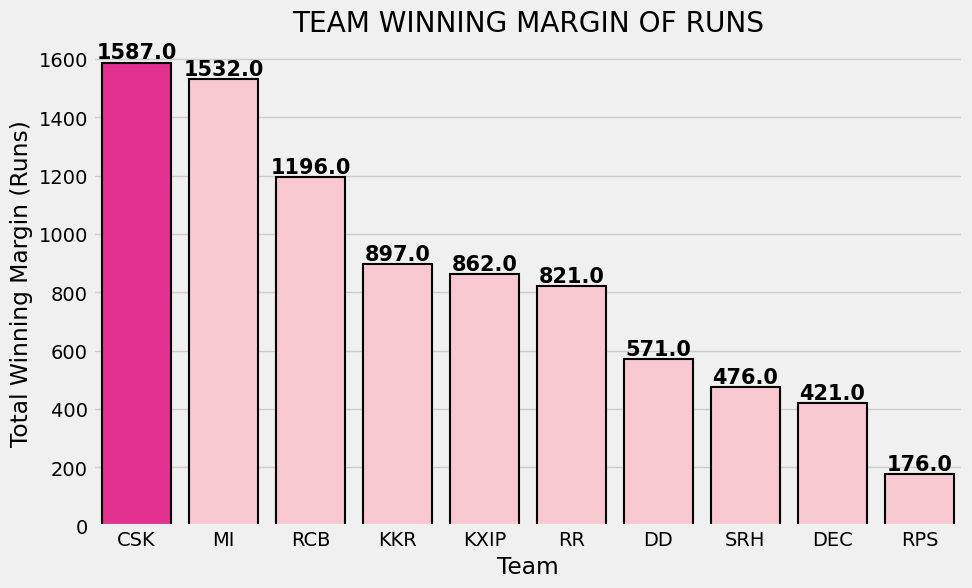

In [50]:
run_margin = (
    ipl_matches[ipl_matches['win_by_runs'] > 0]
    .groupby('winner')['win_by_runs']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
run_margin.columns = ['Team', 'Total Winning Margin (Runs)']
mlt.figure(figsize=(10,6))
colors=['pink']*len(run_margin)
colors[0]='deeppink'
ax=sns.barplot(data=run_margin,x='Team',y='Total Winning Margin (Runs)',palette=colors,edgecolor='black',linewidth=1.5)
for p in ax.patches:
    ax.annotate(
        format((p.get_height())),
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=15,
        fontweight='bold'
    )
mlt.title("TEAM WINNING MARGIN OF RUNS")
mlt.show()

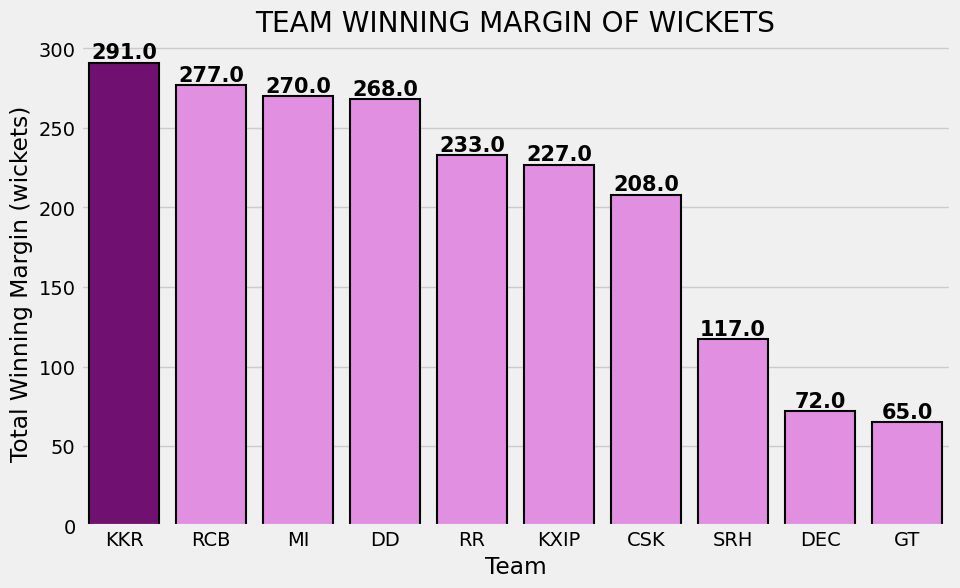

In [51]:
wicket_margin = (
    ipl_matches[ipl_matches['win_by_wickets'] > 0]
    .groupby('winner')['win_by_wickets']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
wicket_margin.columns = ['Team', 'Total Winning Margin (wickets)']
mlt.figure(figsize=(10,6))
colors=['violet']*len(wicket_margin)
colors[0]='purple'
ax=sns.barplot(data=wicket_margin,x='Team',y='Total Winning Margin (wickets)',palette=colors,edgecolor='black',linewidth=1.5)
for p in ax.patches:
    ax.annotate(
        format((p.get_height())),
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=15,
        fontweight='bold'
    )
mlt.title("TEAM WINNING MARGIN OF WICKETS")
mlt.show()

In [52]:
top_wicket_wins = (
    ipl_matches[ipl_matches['win_by_wickets'] > 0]['winner']
    .value_counts()
    .head(10)
    .reset_index()
)

top_wicket_wins.columns = ['Team', 'Wins by Wickets']

top_wicket_wins.style.set_caption(" Top 10 Teams with Most Wins by Wickets").background_gradient(cmap='BuGn')

,Team,Wins by Wickets
0,KKR,46
1,MI,44
2,RCB,42
3,DD,41
4,RR,38
5,KXIP,36
6,CSK,33
7,SRH,18
8,GT,12
9,DEC,11


In [53]:
top_run_wins = (
    ipl_matches[ipl_matches['win_by_runs'] > 0]['winner']
    .value_counts()
    .head(10)
    .reset_index()
)

top_run_wins.columns = ['Team', 'Wins by Runs']

top_run_wins.style.set_caption("Top 10 Teams with Most Wins by Runs").background_gradient(cmap='PuRd')

,Team,Wins by Runs
0,MI,47
1,CSK,46
2,KXIP,32
3,KKR,31
4,RCB,30
5,SRH,23
6,RR,23
7,DD,21
8,DEC,18
9,RPS,7


####SCORE DISTRIBUTION FOR TEAMS BY INNINGS

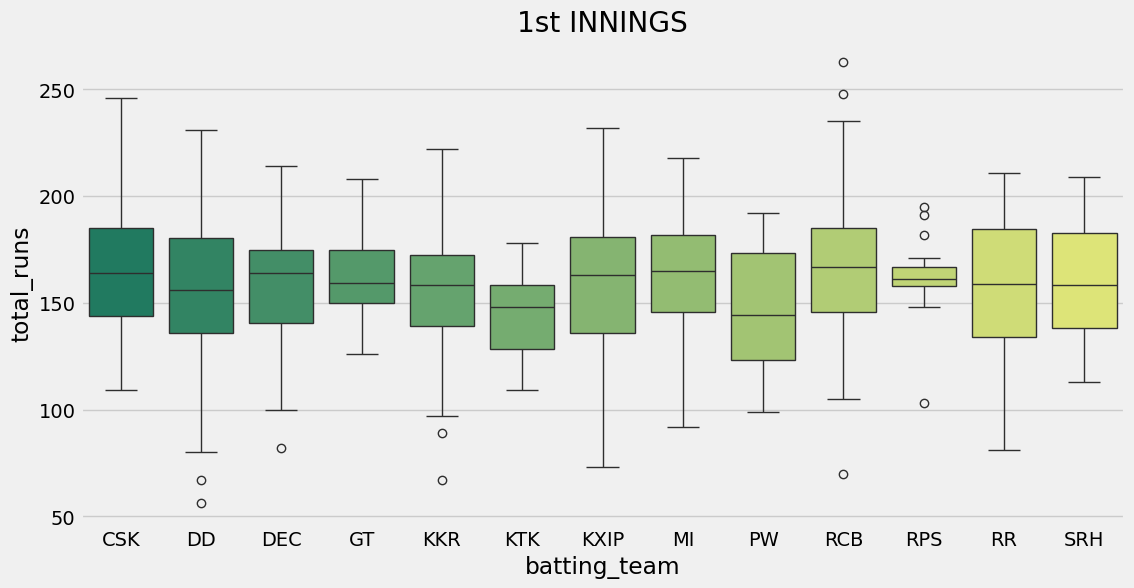

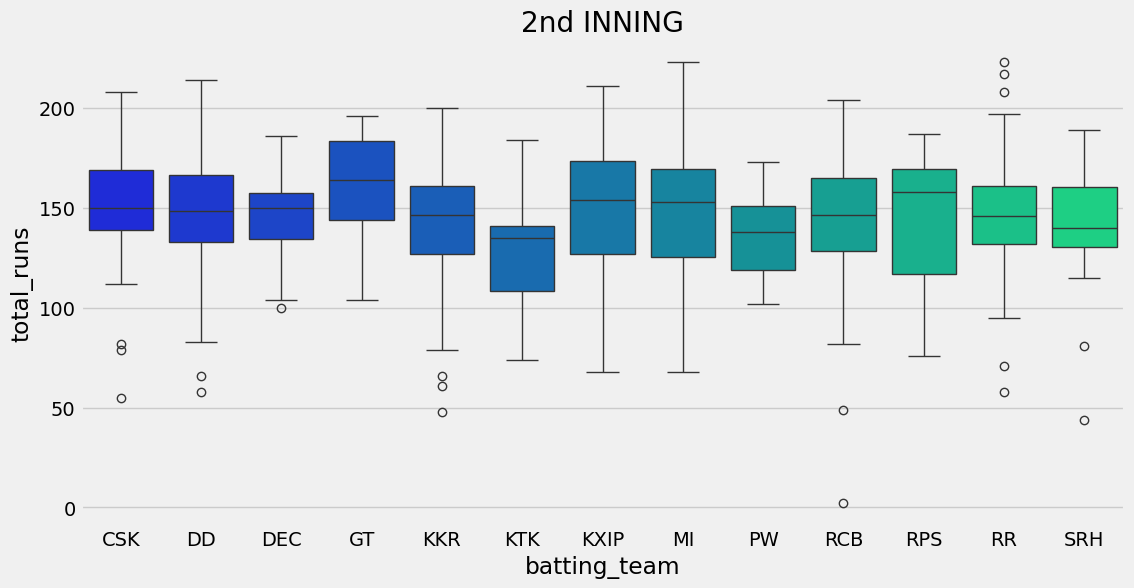

In [54]:
mlt.subplots(figsize=(12,6))
xyz=delivery.groupby(['match_id','inning','batting_team'])['total_runs'].sum().reset_index()
xyz.drop('match_id',axis=1,inplace=True)
xyz=xyz.sort_values(by=['batting_team','total_runs'],ascending=True)
score_1_inning=xyz[xyz['inning']==1]
score_2_inning=xyz[xyz['inning']==2]
sns.boxplot(x='batting_team',y='total_runs',data=score_1_inning,palette='summer').set_title("1st INNINGS")
mlt.show()
sns.boxplot(x='batting_team',y='total_runs',data=score_2_inning,palette='winter').set_title("2nd INNING")
fig=mlt.gcf()
fig.set_size_inches(12,6)

In [55]:
high_scores=delivery.groupby(['match_id','inning','batting_team'])['total_runs'].sum().reset_index()
high_scores=high_scores[high_scores['total_runs']>=200]
high_scores.nlargest(10,'total_runs')

,match_id,inning,batting_team,total_runs
829,411,1,RCB,263
1250,620,1,RCB,248
416,206,1,CSK,246
122,61,1,CSK,240
1134,562,1,RCB,235
596,296,1,KXIP,232
522,259,1,DD,231
981,486,1,KXIP,231
100,50,1,KXIP,230
1170,580,1,RCB,227


In [56]:
high_scores = (
    delivery
    .groupby(
        ['match_id', 'inning', 'batting_team', 'bowling_team']
    )['total_runs']
    .sum()
    .reset_index()
)

high_scores = high_scores[high_scores['total_runs'] >= 200]
print(high_scores.columns)


Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'total_runs'], dtype='object')


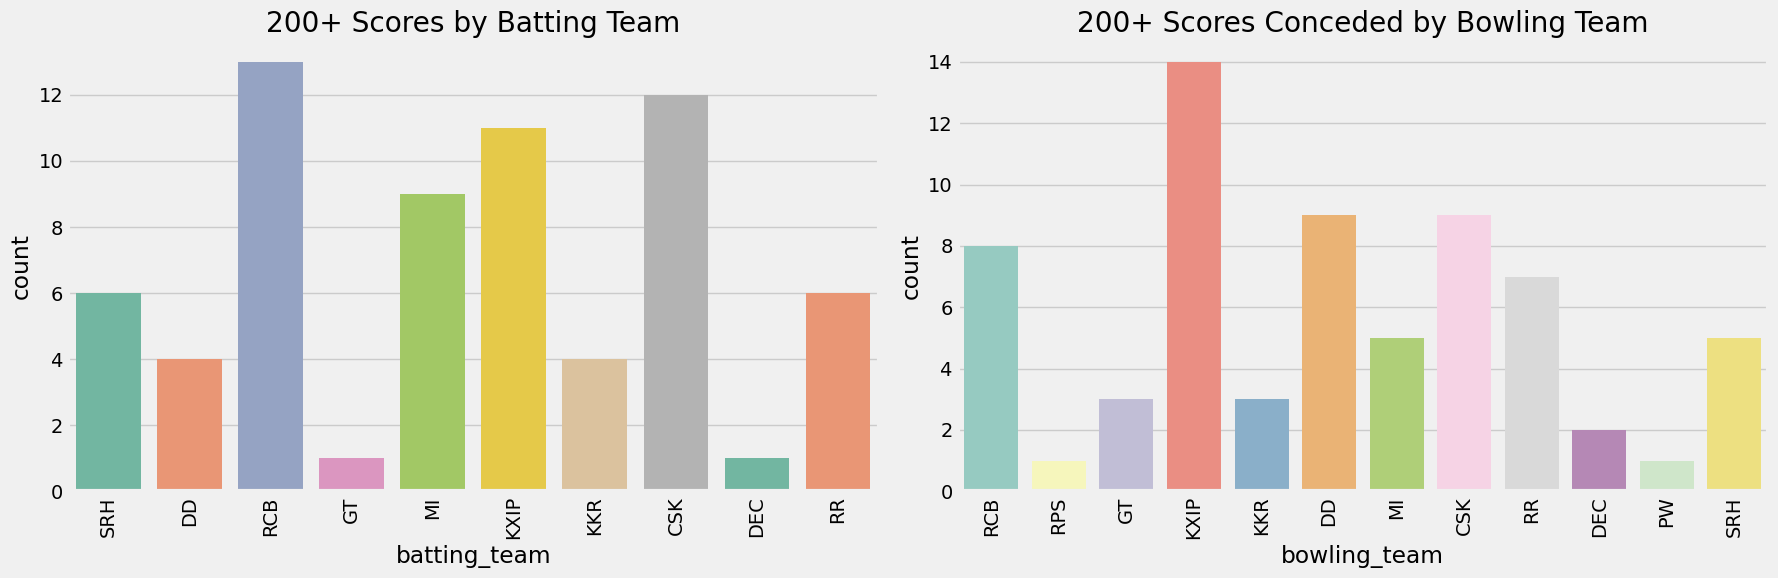

In [57]:
fig, ax = mlt.subplots(1,2, figsize=(18,6))

sns.countplot(
    data=high_scores,
    x='batting_team',
    ax=ax[0],
    palette='Set2'
)

sns.countplot(
    data=high_scores,
    x='bowling_team',
    ax=ax[1],
    palette='Set3'
)

ax[0].tick_params(axis='x', rotation=90)
ax[1].tick_params(axis='x', rotation=90)

ax[0].set_title('200+ Scores by Batting Team')
ax[1].set_title('200+ Scores Conceded by Bowling Team')

mlt.tight_layout()
mlt.show()

In [58]:
print("TEAMS WHO HAVE EVER SCORED 200+RUNS:",list(set(teams)-set(high_scores['batting_team'])))
print("TEAMS WHO HAVE NOT CONCEEDED OVER 200+ RUNS:",list(set(teams)-set(high_scores['bowling_team'])))

TEAMS WHO HAVE EVER SCORED 200+RUNS: ['PW', 'RPS', 'KTK']
TEAMS WHO HAVE NOT CONCEEDED OVER 200+ RUNS: ['KTK']


In [59]:
high = (
    delivery
    .groupby(['match_id', 'inning', 'batting_team', 'bowling_team'])['total_runs']
    .sum()
    .reset_index()
)
high.rename(columns={'total_runs': 'count'}, inplace=True)
high = high[high['count'] >=200]
high = (
    high
    .groupby(['inning', 'batting_team', 'bowling_team'])
    .size()
    .reset_index(name='200+ Scores')
)
high.style.background_gradient(cmap='PuRd')


,inning,batting_team,bowling_team,200+ Scores
0,1,CSK,DD,1
1,1,CSK,KKR,1
2,1,CSK,KXIP,2
3,1,CSK,MI,1
4,1,CSK,RCB,1
5,1,CSK,RR,1
6,1,CSK,SRH,2
7,1,DD,KXIP,1
8,1,DD,MI,1
9,1,DD,RPS,1


In [60]:
innings_score = (
    delivery
    .groupby(['match_id', 'inning', 'batting_team'])['total_runs']
    .sum()
    .reset_index()
)
first_innings = innings_score[innings_score['inning'] == 1].copy()
second_innings = innings_score[innings_score['inning'] == 2].copy()
first_innings = first_innings.rename(columns={
    'batting_team': 'Team 1',
    'total_runs': 'First Innings Score'
})
second_innings = second_innings.rename(columns={
    'batting_team': 'Team 2',
    'total_runs': 'Second Innings Score'
})
score_compare = pd.merge(
    first_innings[['match_id', 'Team 1', 'First Innings Score']],
    second_innings[['match_id', 'Team 2', 'Second Innings Score']],
    on='match_id'
)
score_compare = score_compare[
    score_compare['First Innings Score'] >= 200
]
score_compare['Chased'] = score_compare['Second Innings Score'] > score_compare['First Innings Score']
score_compare['Chased'] = np.where(
    score_compare['Second Innings Score'] > score_compare['First Innings Score'],
    'Yes',
    'No'
)

score_compare.head()

,match_id,Team 1,First Innings Score,Team 2,Second Innings Score,Chased
0,1,SRH,207,RCB,172,No
8,9,DD,205,RPS,108,No
19,20,RCB,213,GT,192,No
31,32,SRH,207,KXIP,181,No
35,36,SRH,209,KKR,161,No


chances of chasing 200 +target

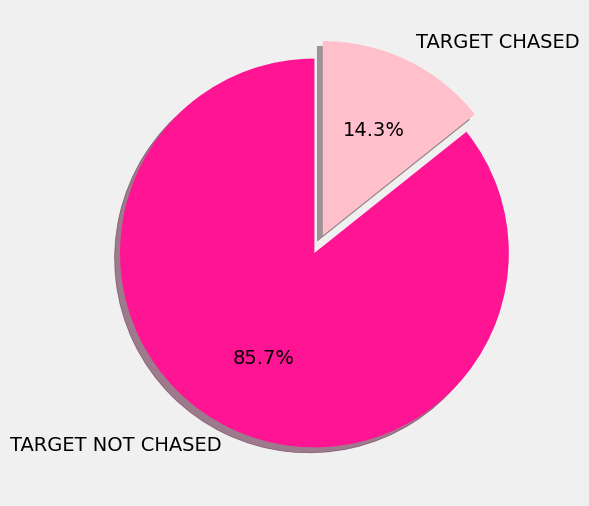

In [61]:
slices = score_compare['Chased'].value_counts().reindex(['No', 'Yes'])
labels=['TARGET NOT CHASED','TARGET CHASED']
mlt.pie(slices,labels=['TARGET NOT CHASED','TARGET CHASED'],colors=['deeppink','pink'],startangle=90,shadow=True,explode=(0,0.1),autopct='%1.1f%%')
fig=mlt.gcf()
fig.set_size_inches(6,6)
mlt.show()

In [62]:
balls = delivery.groupby('batsman')['ball'].count().reset_index(name='Balls')

runs = delivery.groupby('batsman')['batsman_runs'].sum().reset_index(name='Runs')

fours = delivery.groupby('batsman')['batsman_runs'].agg(
    lambda x: (x == 4).sum()
).reset_index(name='Fours')

sixes = delivery.groupby('batsman')['batsman_runs'].agg(
    lambda x: (x == 6).sum()
).reset_index(name='Sixes')

# Team played for
teams = delivery.groupby('batsman')['batting_team'].first().reset_index(name='Team')

# Merge all DataFrames
stats = (
    balls
    .merge(runs, on='batsman')
    .merge(fours, on='batsman')
    .merge(sixes, on='batsman')
    .merge(teams, on='batsman')
)

# Strike Rate
stats['Strike Rate'] = (stats['Runs'] / stats['Balls']) * 100

print(stats.head())

          batsman  Balls  Runs  Fours  Sixes Team  Strike Rate
0  A Ashish Reddy    196   280     16     15  DEC   142.857143
1      A Chandila      7     4      0      0   RR    57.142857
2        A Chopra     75    53      7      0  KKR    70.666667
3     A Choudhary     20    25      1      1  RCB   125.000000
4      A Flintoff     57    62      5      2  CSK   108.771930


In [63]:


def batsman_comparators(stat1, stat2, batsman1, batsman2):

    mlt.figure(figsize=(15, 7))

    # Plot all batsmen
    sns.scatterplot(
        data=stats,
        x=stat1,
        y=stat2,
        hue='Team',
        alpha=0.6,
        s=80
    )

    # First batsman
    bats1 = stats[stats['batsman'].str.contains(batsman1, case=False, na=False)]

    if not bats1.empty:
        x1 = bats1.iloc[0][stat1]
        y1 = bats1.iloc[0][stat2]

        mlt.scatter(x1, y1, color='red', s=250, edgecolors='black', zorder=5)

        mlt.text(
            x1,
            y1,
            bats1.iloc[0]['batsman'],
            fontsize=11,
            fontweight='bold',
            color='red'
        )

    # Second batsman
    bats2 = stats[stats['batsman'].str.contains(batsman2, case=False, na=False)]

    if not bats2.empty:
        x2 = bats2.iloc[0][stat1]
        y2 = bats2.iloc[0][stat2]

        mlt.scatter(x2, y2, color='blue', s=250, edgecolors='black', zorder=5)

        mlt.text(
            x2,
            y2,
            bats2.iloc[0]['batsman'],
            fontsize=11,
            fontweight='bold',
            color='blue'
        )

    mlt.title('BATSMAN COMPARATOR', fontsize=20, fontweight='bold')
    mlt.xlabel(stat1, fontsize=12)
    mlt.ylabel(stat2, fontsize=12)
    mlt.grid(alpha=0.3)
    mlt.legend(title='Team', bbox_to_anchor=(1.02, 1), loc='upper left')
    mlt.show()

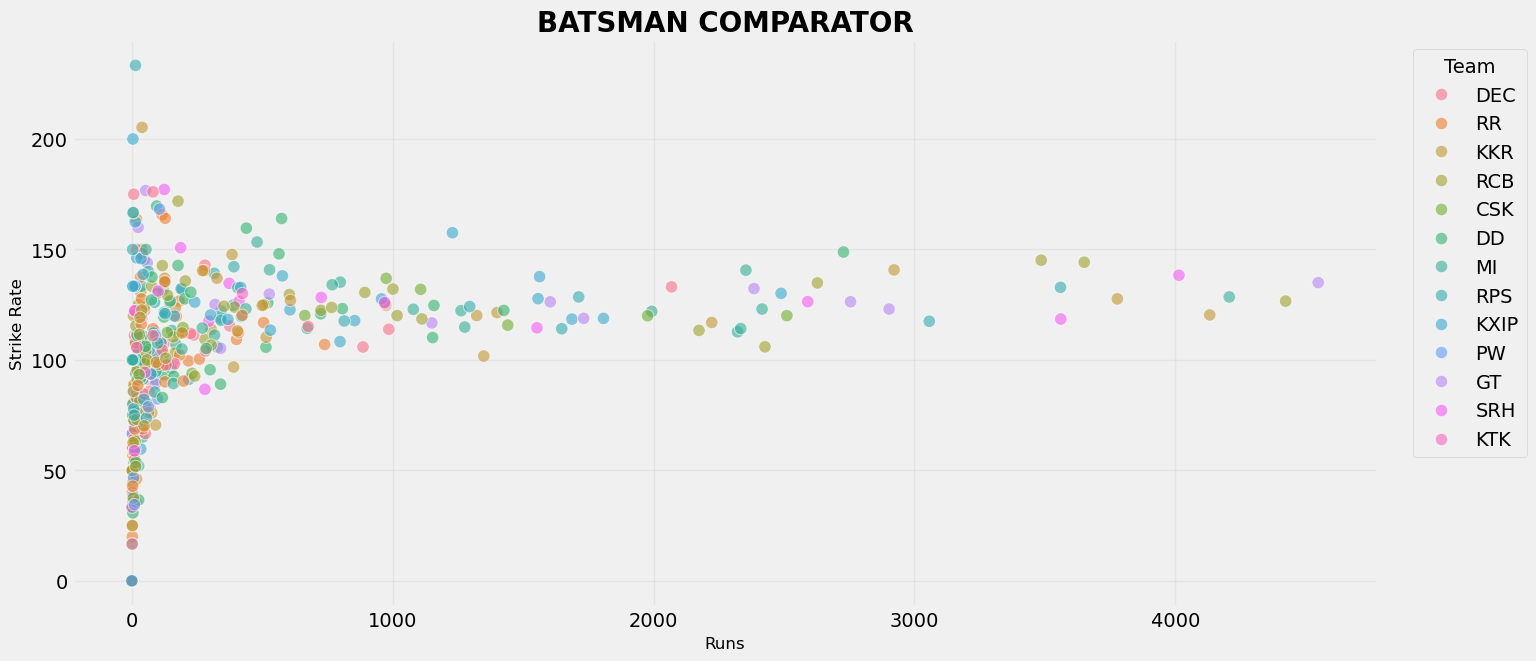

In [64]:
batsman_comparators('Runs', 'Strike Rate', 'Virat', 'Rohit')

In [65]:
print(stats.columns)

Index(['batsman', 'Balls', 'Runs', 'Fours', 'Sixes', 'Team', 'Strike Rate'], dtype='object')


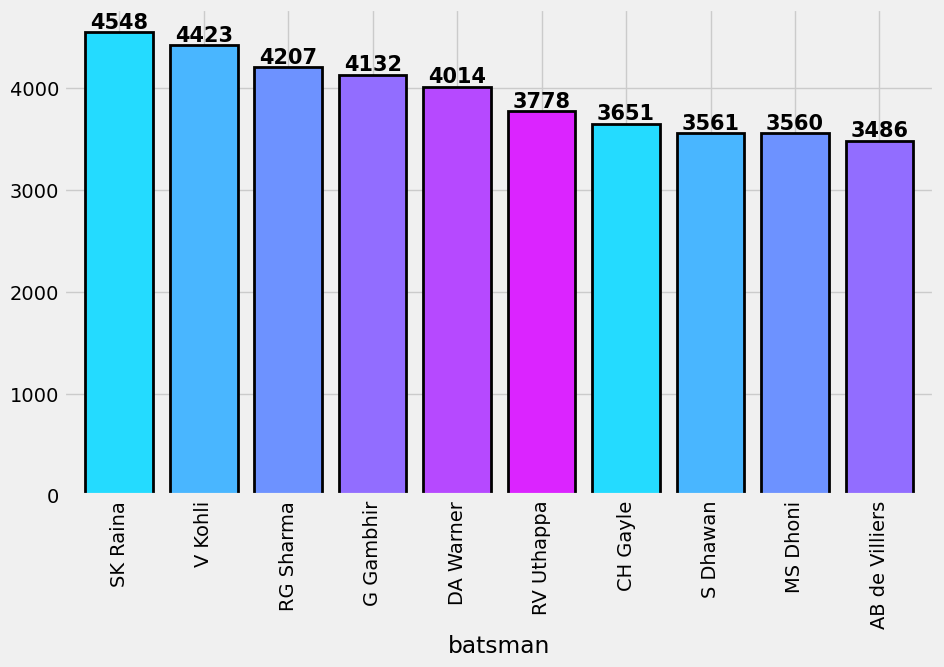

In [66]:
mlt.subplots(figsize=(10,6))
max_runs=delivery.groupby(['batsman'])['batsman_runs'].sum()
ax=max_runs.sort_values(ascending=False)[:10].plot.bar(width=0.8,color=sns.color_palette('cool'),edgecolor='black',linewidth=2)
for p in ax.patches:
    ax.annotate(
        format((p.get_height())),
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=15,
        fontweight='bold'
    )
mlt.show()

In [67]:
top_scores=delivery.groupby(['match_id','batsman','batting_team'])['batsman_runs'].sum().reset_index()
top_scores.sort_values('batsman_runs',ascending=0).head(10)
top_scores.nlargest(10,'batsman_runs')

,match_id,batsman,batting_team,batsman_runs
6200,411,CH Gayle,RCB,175
900,60,BB McCullum,KKR,158
8426,562,AB de Villiers,RCB,133
9257,620,AB de Villiers,RCB,129
5585,372,CH Gayle,RCB,128
3135,206,M Vijay,CSK,127
529,36,DA Warner,SRH,126
7752,516,V Sehwag,KXIP,122
3686,243,PC Valthaty,KXIP,120
4223,279,V Sehwag,DD,119


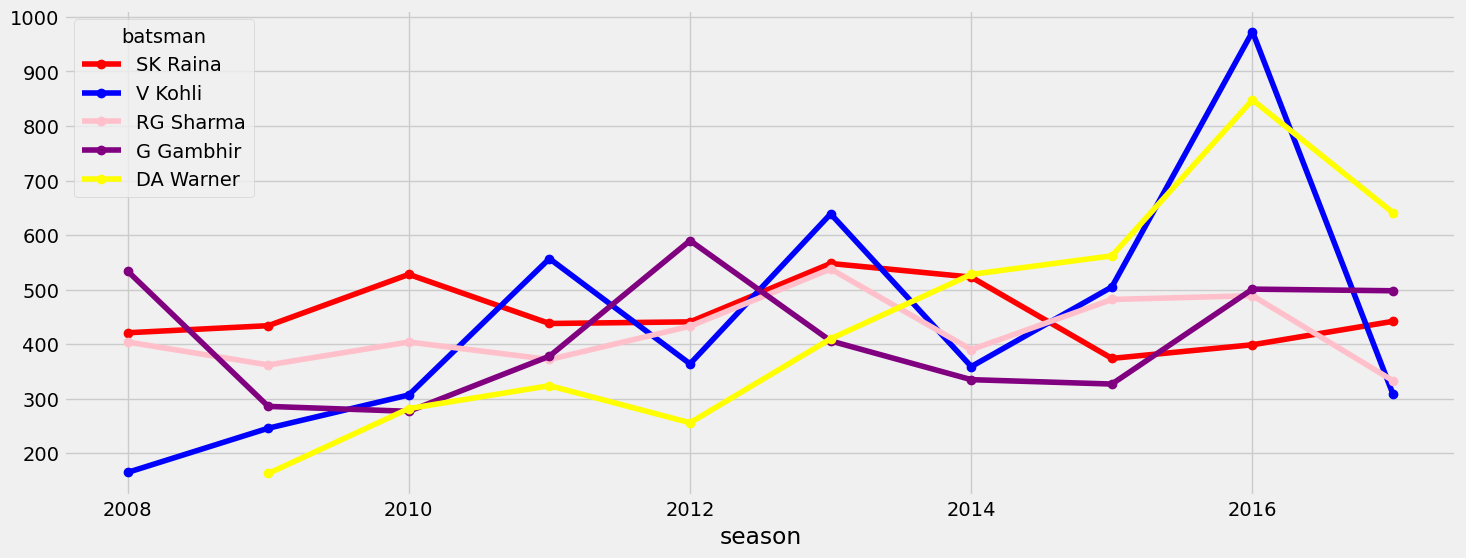

In [68]:
a=batsmen.groupby(['season','batsman'])['batsman_runs'].sum().reset_index()
a=a.groupby(['season','batsman'])['batsman_runs'].sum().unstack().T
a['Total']=a.sum(axis=1)
a=a.sort_values(by='Total',ascending=0)[:5]
a.drop('Total',axis=1,inplace=True)

a.T.plot(color=['red','blue','pink','purple','yellow'],marker='o')
fig=mlt.gcf()
fig.set_size_inches(16,6)
mlt.show()

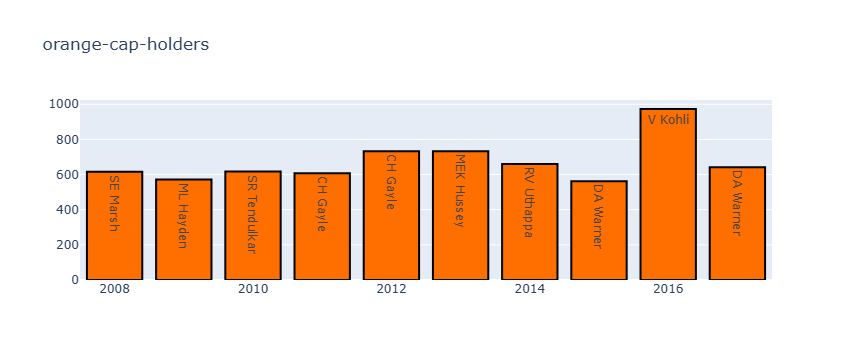

In [69]:
orange = ipl_matches[['id','season']]
# Fixed: Assign the merge result back to orange variable
orange = orange.merge(delivery, left_on='id', right_on='match_id', how='left')
orange = orange.groupby(['season','batsman'])['batsman_runs'].sum().reset_index()
# Fixed: Changed ascending=0 to ascending=False (0 is not a valid boolean value)
orange = orange.sort_values('batsman_runs', ascending=False)
orange = orange.drop_duplicates(subset=['season'], keep='first')
orange = orange.sort_values(by='season')

trace1 = go.Bar(  # Fixed: Changed go.bar to go.Bar (correct capitalization)
    x=orange['season'].values,
    y=orange['batsman_runs'].values,
    name='Total Matches',
    text=orange['batsman'].values,
    marker=dict(
        color='#FF6F00',
        line=dict(color='black', width=2),
        opacity=1
    ))
layout = go.Layout(title="orange-cap-holders")
data = [trace1]
fig = go.Figure(data=data, layout=layout)
py.iplot(fig, filename='stacked-bar')

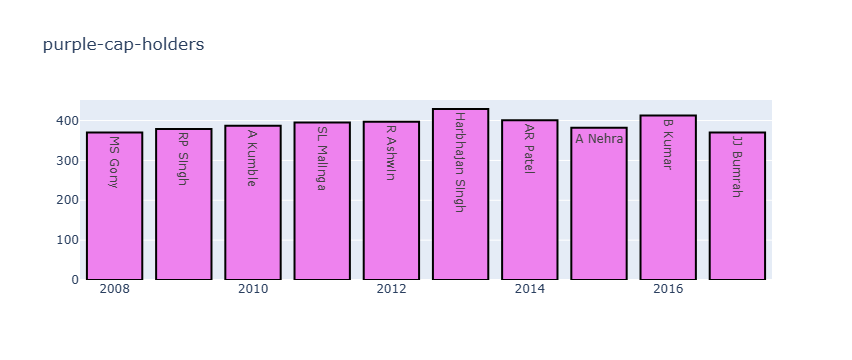

In [70]:
delivery_season = delivery.merge(
    ipl_matches[['id', 'season']],
    left_on='match_id',
    right_on='id'
)

wickets = delivery_season[
    (delivery_season['player_dismissed'].notna()) &
    (delivery_season['dismissal_kind'] != 'run out')
]

purple_cap_season = (
    wickets.groupby(['season', 'bowler'])['player_dismissed']
    .count()
    .reset_index(name='Wickets')
)

purple_cap_winners = (
    purple_cap_season.sort_values(
        ['season', 'Wickets'],
        ascending=False
    )
    .groupby('season')
    .first()
    .reset_index()
)

trace1 = go.Bar(  # Fixed: Changed go.bar to go.Bar (correct capitalization)
    x=purple_cap_winners['season'].values,
    y=purple_cap_winners['Wickets'].values,
    name='Total Matches',
    text=purple_cap_winners['bowler'].values,
    marker=dict(
        color='violet',
        line=dict(color='black', width=2),
        opacity=1
    ))
layout = go.Layout(title="purple-cap-holders")
data = [trace1]
fig = go.Figure(data=data, layout=layout)
py.iplot(fig, filename='stacked-bar')

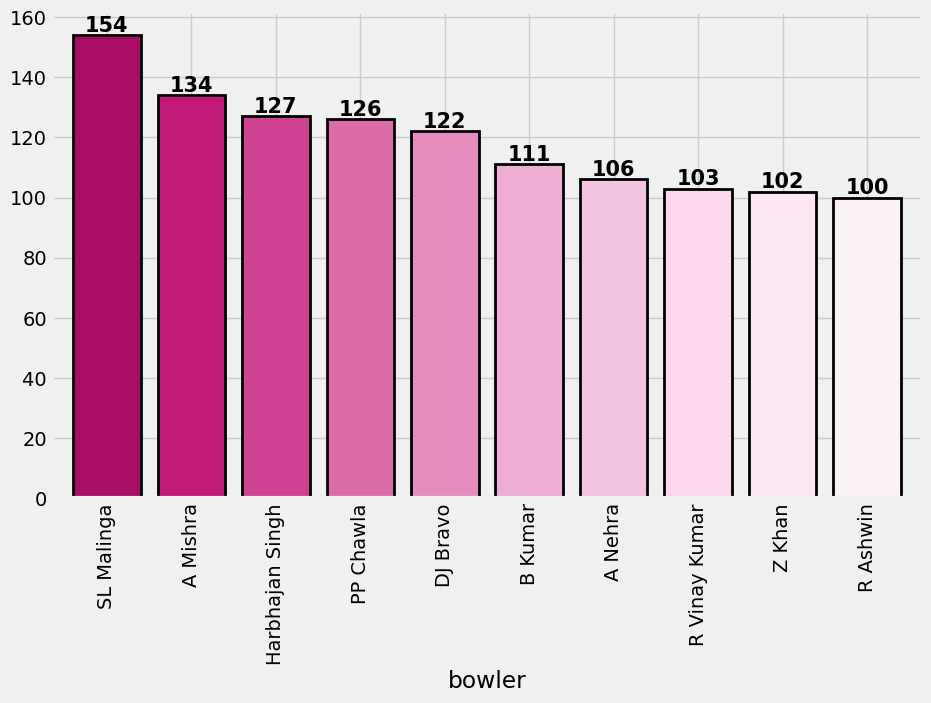

In [71]:
mlt.subplots(figsize=(10,6))
dismissal_kinds=['bowled','caught','lbw','stumped','caught and bowled','hit wicket']
ct=delivery[delivery['dismissal_kind'].isin(dismissal_kinds)]
ax=ct['bowler'].value_counts()[:10].plot.bar(width=0.8,color=sns.color_palette('PiYG',20),edgecolor='black',linewidth=2)
for p in ax.patches:
    ax.annotate(
        format((p.get_height())),
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=15,
        fontweight='bold'
    )
mlt.show()

In [72]:
eco=delivery.groupby(['bowler']).sum(numeric_only=True)
eco['total balls']=delivery['bowler'].value_counts()
eco['overs']=(eco['total balls']//6)
eco[eco['overs']>200].sort_values(by='overs',ascending=0)['overs'].head(5).reset_index()

,bowler,overs
0,Harbhajan Singh,498
1,A Mishra,450
2,SL Malinga,449
3,P Kumar,439
4,PP Chawla,432


In [73]:
eco['economy']=(eco['total_runs']/(eco['overs']))
eco[eco['overs']>300].sort_values('economy')[:10].economy.reset_index().T

,0,1,2,3,4,5,6,7,8,9
bowler,SP Narine,R Ashwin,DW Steyn,SL Malinga,Harbhajan Singh,B Kumar,A Mishra,PP Ojha,Z Khan,P Kumar
economy,6.395706,6.493639,6.615599,6.757238,6.933735,7.046784,7.344444,7.404321,7.546174,7.612756


In [74]:
ipl_matches.head()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2
0,1,2017,Hyderabad,2017-04-05,SRH,RCB,RCB,field,normal,0,SRH,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong
1,2,2017,Pune,2017-04-06,MI,RPS,RPS,field,normal,0,RPS,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi
2,3,2017,Rajkot,2017-04-07,GT,KKR,KKR,field,normal,0,KKR,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan
3,4,2017,Indore,2017-04-08,RPS,KXIP,KXIP,field,normal,0,KXIP,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin
4,5,2017,Bangalore,2017-04-08,RCB,DD,RCB,bat,normal,0,RCB,15,0,KM Jadhav,M Chinnaswamy Stadium,unkown,unkown


In [75]:
matches_played = pd.concat([
    ipl_matches['team1'],
    ipl_matches['team2']
])

matches_played = (
    matches_played
    .value_counts()
    .reset_index()
)
matches_played.columns = ['Team', 'Total Matches']
wins = (
    ipl_matches['winner']
    .value_counts()
    .reset_index()
)
wins.columns = ['Team', 'Wins']
matches_played = matches_played.merge(
    wins,
    on='Team',
    how='left'
)

matches_played['Wins'] = matches_played['Wins'].fillna(0).astype(int)


matches_played = matches_played.sort_values(
    by='Total Matches',
    ascending=False
).reset_index(drop=True)
print(matches_played)

    Team  Total Matches  Wins
0     MI            157    92
1    RCB            152    73
2    KKR            148    77
3   KXIP            148    70
4     DD            147    62
5    CSK            131    79
6     RR            118    63
7    SRH             76    42
8    DEC             75    29
9     PW             46    12
10    GT             30    13
11   RPS             30    15
12   KTK             14     6


In [76]:
ipl_matches.head()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2
0,1,2017,Hyderabad,2017-04-05,SRH,RCB,RCB,field,normal,0,SRH,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong
1,2,2017,Pune,2017-04-06,MI,RPS,RPS,field,normal,0,RPS,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi
2,3,2017,Rajkot,2017-04-07,GT,KKR,KKR,field,normal,0,KKR,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan
3,4,2017,Indore,2017-04-08,RPS,KXIP,KXIP,field,normal,0,KXIP,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin
4,5,2017,Bangalore,2017-04-08,RCB,DD,RCB,bat,normal,0,RCB,15,0,KM Jadhav,M Chinnaswamy Stadium,unkown,unkown


In [77]:
team_mapping={'SRH':1,
              'MI':2,
              'GT':3,
              'RPS':4,
              'RCB':5,
              'KKR':6,
              'DD':7,
              'KXIP':8,
              'CSK':9,
              'RR':10,
              'DEC':11,
              'KTK':12,
              'PW':13,
              'RPS':14}

ipl_matches['team1'] = ipl_matches['team1'].map(team_mapping)
ipl_matches['team2'] = ipl_matches['team2'].map(team_mapping)
ipl_matches['winner'] = ipl_matches['winner'].map(team_mapping)
ipl_matches['toss_winner'] = ipl_matches['toss_winner'].map(team_mapping)

In [78]:
player_of_match_mapping = {venue: i for i, venue in enumerate(ipl_matches['player_of_match'].unique())}
ipl_matches['player_of_match'] = ipl_matches['player_of_match'].map(player_of_match_mapping)

In [79]:
ipl_matches.head()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2
0,1,2017,Hyderabad,2017-04-05,1,5,5,field,normal,0,1.0,35,0,0,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong
1,2,2017,Pune,2017-04-06,2,14,14,field,normal,0,14.0,0,7,1,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi
2,3,2017,Rajkot,2017-04-07,3,6,6,field,normal,0,6.0,0,10,2,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan
3,4,2017,Indore,2017-04-08,14,8,8,field,normal,0,8.0,0,6,3,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin
4,5,2017,Bangalore,2017-04-08,5,7,5,bat,normal,0,5.0,15,0,4,M Chinnaswamy Stadium,unkown,unkown


In [80]:
venue_mapping = {venue: i for i, venue in enumerate(ipl_matches['venue'].unique())}
ipl_matches['venue'] = ipl_matches['venue'].map(venue_mapping)

In [81]:
toss_temp={'field':1,'bat':0}
ipl_matches['toss_decision'] = ipl_matches['toss_decision'].map(toss_temp)

In [82]:
season_mapping = {venue: i for i, venue in enumerate(ipl_matches['season'].unique())}
ipl_matches['season'] = ipl_matches['season'].map(season_mapping)

In [83]:
ipl_matches.tail()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2
631,632,9,Raipur,2016-05-22,7,5,5,1,normal,0,5.0,0,6,138,30,A Nand Kishore,BNJ Oxenford
632,633,9,Bangalore,2016-05-24,3,5,5,1,normal,0,5.0,0,4,90,4,AK Chaudhary,HDPK Dharmasena
633,634,9,Delhi,2016-05-25,1,6,6,1,normal,0,1.0,22,0,191,7,M Erasmus,C Shamshuddin
634,635,9,Delhi,2016-05-27,3,1,1,1,normal,0,1.0,0,4,29,7,M Erasmus,CK Nandan
635,636,9,Bangalore,2016-05-29,1,5,1,0,normal,0,1.0,8,0,201,4,HDPK Dharmasena,BNJ Oxenford


In [84]:
X=ipl_matches[['id','season','team1','team2','toss_winner','toss_decision','venue']]

In [85]:
X.head()

,id,season,team1,team2,toss_winner,toss_decision,venue
0,1,0,1,5,5,1,0
1,2,0,2,14,14,1,1
2,3,0,3,6,6,1,2
3,4,0,14,8,8,1,3
4,5,0,5,7,5,0,4


In [87]:
Y=ipl_matches[['winner']]

In [97]:

print(Y.isnull().sum())

winner    0
dtype: int64


In [96]:
Y = Y.fillna(0)

In [98]:
Y.head()

,winner
0,1.0
1,14.0
2,6.0
3,8.0
4,5.0


In [99]:
from sklearn.model_selection import train_test_split  
X_train,X_test,Y_train,Y_test = train_test_split(
    X, 
    Y, 
    test_size=0.2, 
    random_state=42 
)

In [100]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train,Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [103]:
y_pred = lr.predict(X_test)

In [105]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

print("The accuracy of LR :", accuracy_score(Y_test, y_pred))

print("The precision of LR :",
      precision_score(Y_test, y_pred, average='weighted'))

print("The recall of LR :",
      recall_score(Y_test, y_pred, average='weighted'))

print("The F1 score of LR :",
      f1_score(Y_test, y_pred, average='weighted'))

lr_accuracy = accuracy_score(Y_test, y_pred)

lr_precision = precision_score(
    Y_test, y_pred,
    average='weighted'
)

lr_recall = recall_score(
    Y_test, y_pred,
    average='weighted'
)

lr_f1 = f1_score(
    Y_test, y_pred,
    average='weighted'
)

cm = confusion_matrix(Y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

The accuracy of LR : 0.3046875
The precision of LR : 0.28165007560483873
The recall of LR : 0.3046875
The F1 score of LR : 0.2805139512701632

Confusion Matrix:
[[ 0  0  0  0  1  0  0  0  0  0  0  0  0]
 [ 0  2  5  0  0  0  0  0  0  0  0  0  0]
 [ 0  1 10  0  0  0  3  0  0  0  0  0  1]
 [ 0  3  1  0  0  1  0  0  0  0  0  0  0]
 [ 0  1  9  0  1  2  1  0  0  1  2  0  0]
 [ 0  1  3  0  1  4  1  4  1  0  1  0  1]
 [ 0  0  0  0  0  0  1  1  4  1  2  0  0]
 [ 0  0  2  0  0  2  0  7  0  2  0  0  0]
 [ 0  0  1  0  1  2  0  2  9  5  2  0  0]
 [ 0  0  0  0  2  1  1  1  3  4  1  0  0]
 [ 0  0  0  0  0  0  1  0  2  1  0  0  0]
 [ 0  0  0  0  0  0  0  0  1  1  0  0  0]
 [ 0  0  0  0  0  0  0  1  0  1  0  0  1]]


In [110]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train,Y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [111]:
y_pred = knn.predict(X_test)

In [112]:


print("The accuracy of KNN :", accuracy_score(Y_test, y_pred))

print("The precision of KNN :",
      precision_score(Y_test, y_pred, average='weighted'))

print("The recall of KNN :",
      recall_score(Y_test, y_pred, average='weighted'))

print("The F1 score of KNN :",
      f1_score(Y_test, y_pred, average='weighted'))

knn_accuracy = accuracy_score(Y_test, y_pred)

knn_precision = precision_score(
    Y_test, y_pred,
    average='weighted'
)

knn_recall = recall_score(
    Y_test, y_pred,
    average='weighted'
)

knn_f1 = f1_score(
    Y_test, y_pred,
    average='weighted'
)

cm = confusion_matrix(Y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

The accuracy of KNN : 0.0859375
The precision of KNN : 0.09204858315176204
The recall of KNN : 0.0859375
The F1 score of KNN : 0.08070650314506739

Confusion Matrix:
[[0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 2 3 0 0 0 1 0 1 0 0 0 0]
 [0 3 3 0 4 0 1 2 0 0 1 0 1]
 [0 2 1 0 0 0 2 0 0 0 0 0 0]
 [0 2 7 1 1 0 2 1 1 1 0 0 1]
 [0 2 5 0 5 0 3 1 1 0 0 0 0]
 [0 0 2 0 0 2 0 1 3 0 1 0 0]
 [0 1 2 0 1 2 1 1 3 0 2 0 0]
 [1 0 4 0 5 3 0 3 3 2 0 1 0]
 [0 0 1 0 2 2 0 4 2 1 1 0 0]
 [0 0 0 0 2 0 0 1 1 0 0 0 0]
 [0 0 0 0 0 1 0 0 1 0 0 0 0]
 [0 0 1 0 0 1 1 0 0 0 0 0 0]]


In [113]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(
    random_state=42
)
dt.fit(
    X_train,
    Y_train
)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [114]:
y_pred = dt.predict(X_test)

In [115]:


print("The accuracy of DT:", accuracy_score(Y_test, y_pred))

print("The precision of DT:",
      precision_score(Y_test, y_pred, average='weighted'))

print("The recall of DT :",
      recall_score(Y_test, y_pred, average='weighted'))

print("The F1 score of DT :",
      f1_score(Y_test, y_pred, average='weighted'))

dt_accuracy = accuracy_score(Y_test, y_pred)

dt_precision = precision_score(
    Y_test, y_pred,
    average='weighted'
)

dt_recall = recall_score(
    Y_test, y_pred,
    average='weighted'
)

dt_f1 = f1_score(
    Y_test, y_pred,
    average='weighted'
)

cm = confusion_matrix(Y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

The accuracy of DT: 0.5078125
The precision of DT: 0.5785337094907408
The recall of DT : 0.5078125
The F1 score of DT : 0.5221650991759686

Confusion Matrix:
[[ 0  0  0  0  0  0  0  0  0  1  0  0  0  0]
 [ 0  4  0  0  0  1  0  1  1  0  0  0  0  0]
 [ 0  0 10  0  0  0  4  0  0  0  1  0  0  0]
 [ 0  0  0  2  2  0  1  0  0  0  0  0  0  0]
 [ 3  0  1  0  5  3  1  1  1  1  0  0  0  1]
 [ 0  1  0  0  0 14  1  0  1  0  0  0  0  0]
 [ 0  0  0  0  0  3  3  0  0  0  2  1  0  0]
 [ 0  0  2  0  0  3  1  5  0  0  1  0  0  1]
 [ 0  0  1  0  1  1  2  4 11  0  0  1  1  0]
 [ 0  0  0  0  1  1  2  1  0  8  0  0  0  0]
 [ 0  0  1  0  1  0  1  0  0  0  0  1  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  1  0  0  0  1  0]
 [ 0  0  0  0  0  1  0  0  0  0  0  0  0  2]]


In [116]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
)

In [117]:
rf.fit(X_train, Y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [118]:
y_pred = rf.predict(X_test)

In [119]:
print("The accuracy of RF:", accuracy_score(Y_test, y_pred))

print("The precision of RF:",
      precision_score(Y_test, y_pred, average='weighted'))

print("The recall of RF:",
      recall_score(Y_test, y_pred, average='weighted'))

print("The F1 score of RF :",
      f1_score(Y_test, y_pred, average='weighted'))

rf_accuracy = accuracy_score(Y_test, y_pred)

rf_precision = precision_score(
    Y_test, y_pred,
    average='weighted'
)

rf_recall = recall_score(
    Y_test, y_pred,
    average='weighted'
)

rf_f1 = f1_score(
    Y_test, y_pred,
    average='weighted'
)

cm = confusion_matrix(Y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

The accuracy of RF: 0.5390625
The precision of RF: 0.562732100415924
The recall of RF: 0.5390625
The F1 score of RF : 0.5368709415584415

Confusion Matrix:
[[ 0  0  0  0  1  0  0  0  0  0  0  0  0]
 [ 0  4  0  0  0  1  0  1  1  0  0  0  0]
 [ 0  1 10  0  0  0  3  0  0  1  0  0  0]
 [ 0  0  0  1  2  0  1  1  0  0  0  0  0]
 [ 0  2  2  0  9  0  0  0  2  2  0  0  0]
 [ 0  0  2  0  1 10  1  2  1  0  0  0  0]
 [ 0  0  0  0  0  3  4  0  1  0  0  1  0]
 [ 0  0  2  0  0  1  2  7  0  0  1  0  0]
 [ 0  0  1  0  3  2  0  4 10  0  1  1  0]
 [ 0  0  0  0  0  0  1  2  2  8  0  0  0]
 [ 0  0  1  0  1  0  0  0  0  0  2  0  0]
 [ 0  0  0  0  0  0  0  0  1  0  0  1  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  3]]


In [121]:
model_results = {
    'Model': ['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest'],
    'Accuracy': [lr_accuracy, knn_accuracy, dt_accuracy, rf_accuracy],
    'Precision': [lr_precision, knn_precision, dt_precision, rf_precision],
    'Recall': [lr_recall, knn_recall, dt_recall, rf_recall],
    'F1-Score': [lr_f1, knn_f1, dt_f1, rf_f1]
}

results_df = pd.DataFrame(model_results)

results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.304688,0.281650,0.304688,0.280514
1,KNN,0.085938,0.092049,0.085938,0.080707
2,Decision Tree,0.507812,0.578534,0.507812,0.522165
3,Random Forest,0.539062,0.562732,0.539062,0.536871
